# Librairies 📚

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import missingno as msno
import math
import re
from scipy.stats import kruskal
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler, RobustScaler
from dython.nominal import (
    associations,
    correlation_ratio,  # eta²
    cramers_v,          # V de Cramér
    theils_u            # Alternative asymétrique
)
import pingouin as pg

import sys
import os

sys.path.append(os.path.abspath(".."))  # si notebook dans /notebooks

import src.outliers_function as of
import src.association_report_function as ar
import src.analyse_bivariee as ab
import importlib
importlib.reload(of)

pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:,.2f}'.format


# Import de la table 🪑

In [73]:
building_consumption = pd.read_csv("/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/data/external/2016_Building_Energy_Benchmarking.csv")

In [74]:
# On regarde comment un batiment est défini dans ce jeu de données 
building_consumption.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",NaN,61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,"98,101.00",0659000475,7,DOWNTOWN,47.61,-122.34,1969,1.00,41,956110,196718,759392,Hotel,Hotel,"756,493.00",NaN,NaN,NaN,NaN,NaN,43.00,96.00,97.70,241.90,244.10,"72,587,024.00","73,937,112.00","21,566,554.00","14,515,435.00","49,526,664.00","14,938.00","1,493,800.00",False,NaN,Compliant,NaN,"2,089.28",2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,"98,101.00",0659000640,7,DOWNTOWN,47.61,-122.34,1926,1.00,10,61320,0,61320,Hotel,Hotel,"61,320.00",NaN,NaN,NaN,NaN,NaN,56.00,110.80,113.30,216.20,224.00,"6,794,584.00","6,946,800.50","2,214,446.25","811,525.31","2,768,924.00","18,112.13","1,811,213.00",False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,"98,121.00",0659000970,7,DOWNTOWN,47.61,-122.34,1980,1.00,18,175580,62000,113580,"Hotel, Parking, Swimming Pool",Hotel,"123,445.00",Parking,"68,009.00",Swimming Pool,0.00,NaN,75.00,114.80,118.70,211.40,215.60,"14,172,606.00","14,656,503.00",0.00,"1,573,448.62","5,368,607.00","88,039.98","8,803,998.00",False,NaN,Compliant,NaN,505.01,2.88


In [75]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
building_consumption.info()

<class 'pandas.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   str    
 3   PrimaryPropertyType              3376 non-null   str    
 4   PropertyName                     3376 non-null   str    
 5   Address                          3376 non-null   str    
 6   City                             3376 non-null   str    
 7   State                            3376 non-null   str    
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   str    
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   str    
 12  Latitude                       

In [76]:
df = building_consumption.copy()

# Etape 1 - Analyse exploratoire 🕵️‍♀️

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Qelques pistes d'analyse : 

* Identifier les colonnes avec une majorité de valeurs manquantes ou constantes en utilisant la méthode value_counts() de Pandas
* Mettre en evidence les différences entre les immeubles mono et multi-usages
* Utiliser des pairplots et des boxplots pour faire ressortir les outliers ou des batiments avec des valeurs peu cohérentes d'un point de vue métier 

Pour vous inspirer, ou comprendre l'esprit recherché dans une analyse exploratoire, vous pouvez consulter ce notebook en ligne : https://www.kaggle.com/code/pmarcelino/comprehensive-data-exploration-with-python. Il ne s'agit pas d'un modèle à suivre à la lettre ni d'un template d'analyses attendues pour ce projet. 

## Nettoyage des données

In [77]:
df.shape

(3376, 46)

### Valeurs nulles

In [78]:
df.isna().mean().sort_values(ascending=False).head(15)

Comments                          1.00
Outlier                           0.99
YearsENERGYSTARCertified          0.96
ThirdLargestPropertyUseType       0.82
ThirdLargestPropertyUseTypeGFA    0.82
SecondLargestPropertyUseType      0.50
SecondLargestPropertyUseTypeGFA   0.50
ENERGYSTARScore                   0.25
LargestPropertyUseTypeGFA         0.01
LargestPropertyUseType            0.01
ZipCode                           0.00
ListOfAllPropertyUseTypes         0.00
Electricity(kWh)                  0.00
SourceEUIWN(kBtu/sf)              0.00
GHGEmissionsIntensity             0.00
dtype: float64

<Axes: >

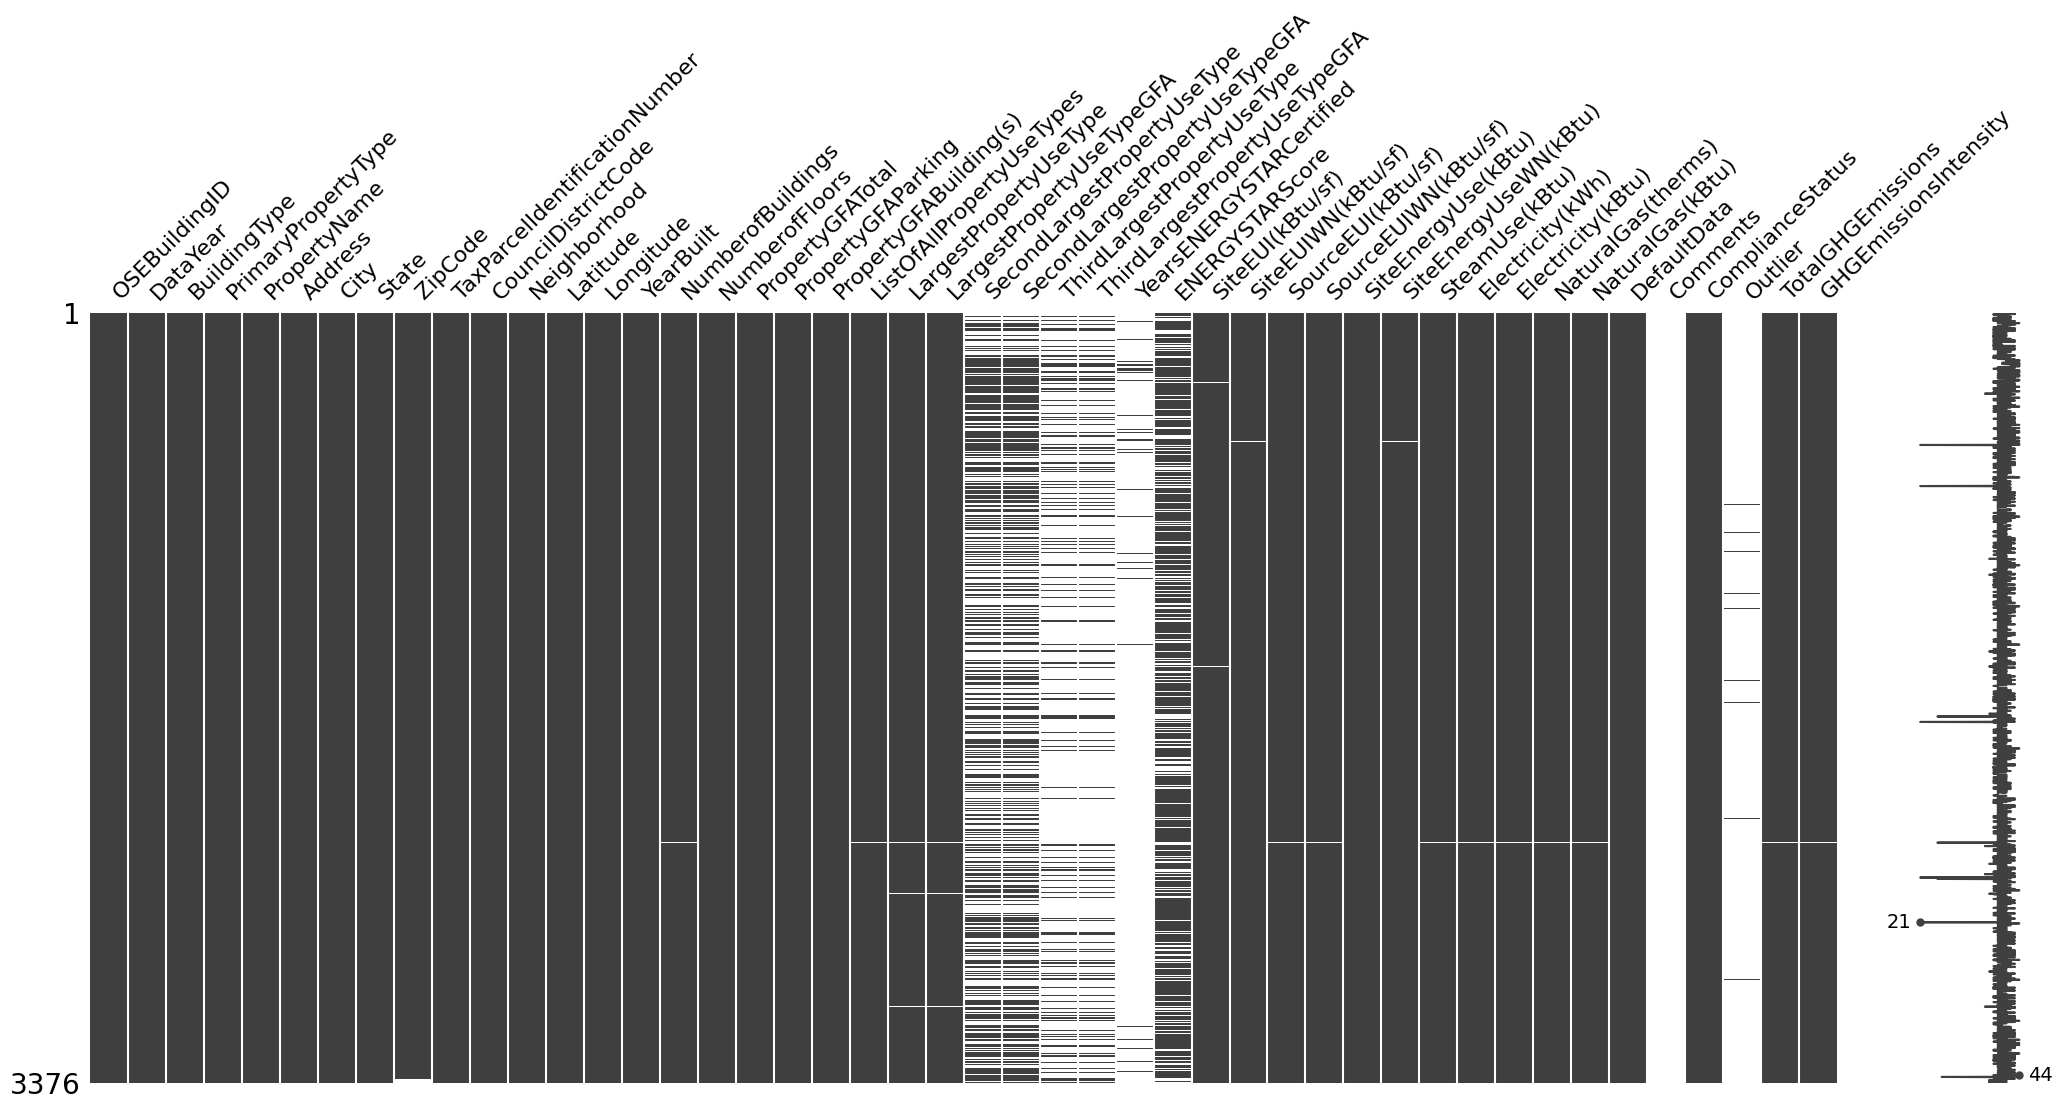

In [79]:
msno.matrix(df)

<Axes: >

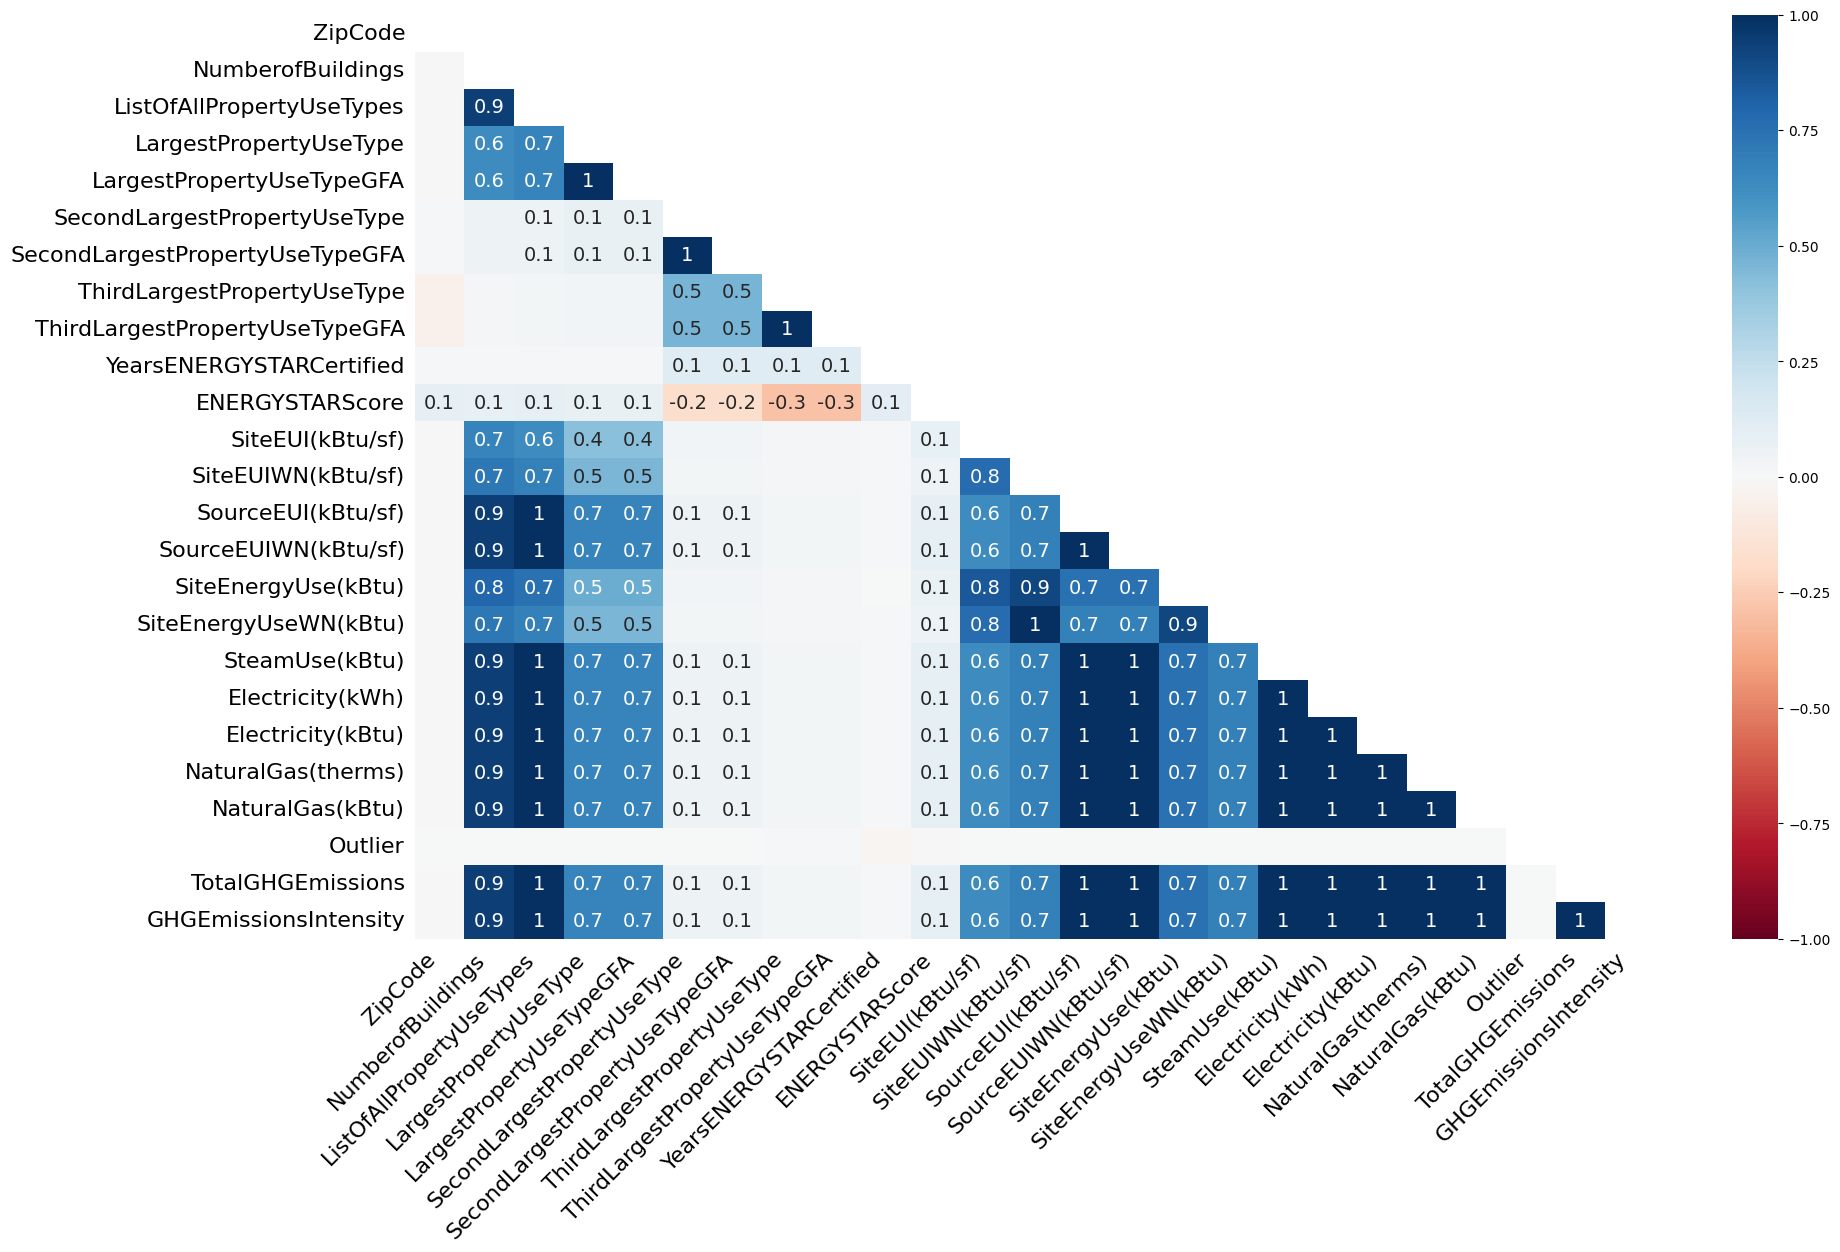

In [80]:
msno.heatmap(df)

<Axes: >

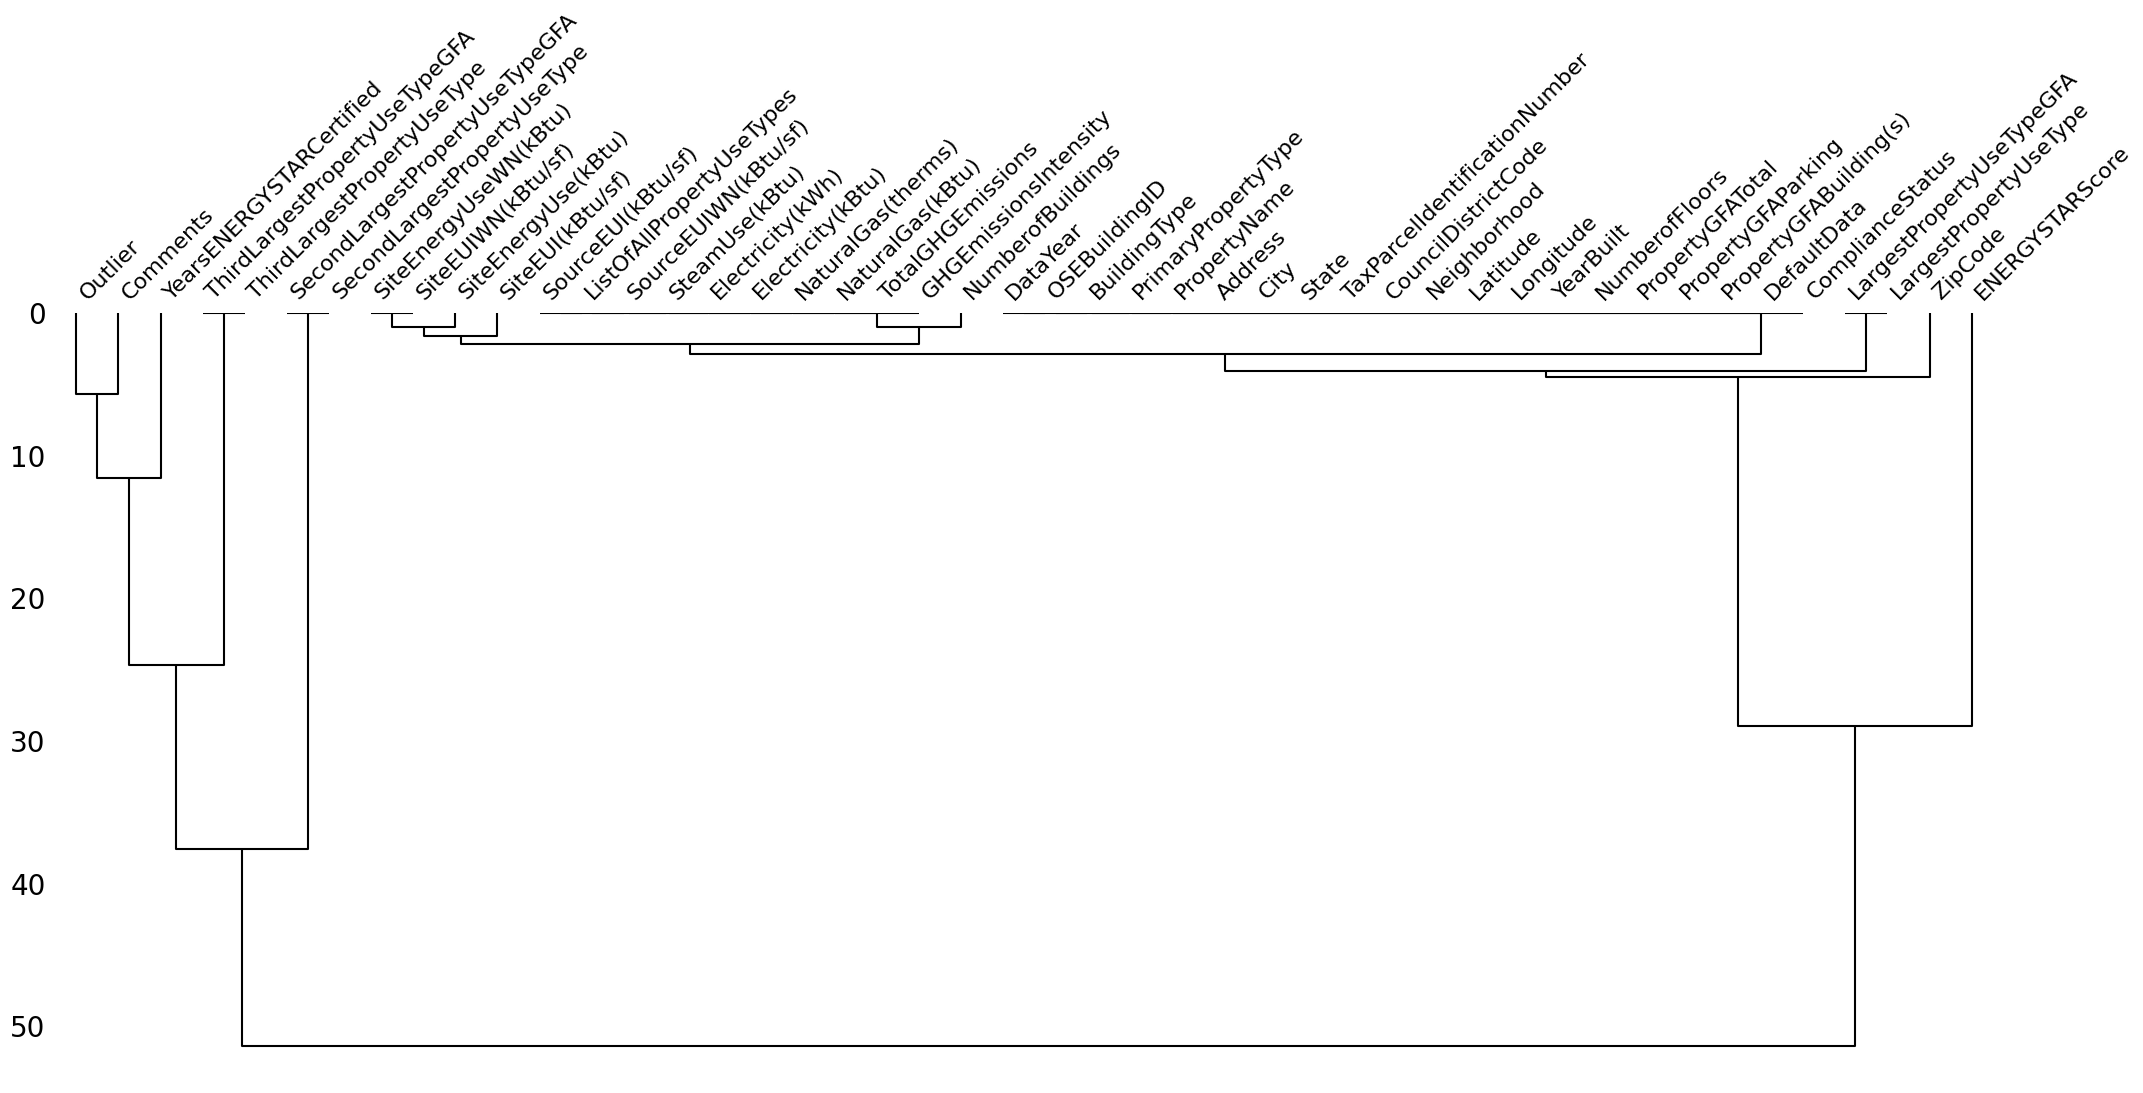

In [81]:
msno.dendrogram(df)

#### Colonne Comments ❌

In [82]:
df.drop(columns="Comments",inplace=True)

#### Colonne Outliers ✅

In [83]:
df[df["Outlier"].notna()]["Outlier"].value_counts()
# la colonne outliers a beaucoup de valeur vide mais elle a toutefois son utilité. Je vais la garder pour le moment.

Outlier
Low outlier     23
High outlier     9
Name: count, dtype: int64

#### Colonne YearsENERGYSTARCertified ❌ (création année's + nb_certification + first_cert_year) ✅

In [84]:
df[df["YearsENERGYSTARCertified"].notna()].sample()
# la colonne très intéressante, il faut :
# - Séparer les années tous les 4 caractères 
# - Créer les dummies par année

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
1453,21862,2016,Multifamily HR (10+),High-Rise Multifamily,Escala,1920 4th Ave,Seattle,WA,"98,101.00",2382000000,7,DOWNTOWN,47.61,-122.34,2010,1.00,31,480789,0,480789,"Multifamily Housing, Parking, Retail Store",Multifamily Housing,"581,843.00",Parking,"205,632.00",Retail Store,"11,682.00",2016,86.00,33.50,36.00,77.00,80.10,"19,897,354.00","21,361,874.00",0.00,"3,477,144.50","11,864,017.00","80,333.36","8,033,336.00",False,Compliant,NaN,509.36,1.06


In [85]:
def split_years(x):
    if pd.isna(x):
        return []
    x = str(x)
    return [x[i:i+4] for i in range(0, len(x), 4)]

df["Years_list"] = df["YearsENERGYSTARCertified"].apply(split_years)

In [86]:
df[df["YearsENERGYSTARCertified"].notna()][["YearsENERGYSTARCertified", "Years_list"]]

,YearsENERGYSTARCertified,Years_list
37,2016,[2016]
44,2016,[2016]
53,2014,[2014]
116,2016,[2016]
137,2016,[2016]
...,...,...
3281,20172016,"[2017, 2016]"
3293,2017,[2017]
3304,20172016,"[2017, 2016]"
3317,2017,[2017]


In [87]:
# Créer les dummies (One-hot encoding multi-label)
mlb = MultiLabelBinarizer()

years_dummies = pd.DataFrame(
    mlb.fit_transform(df["Years_list"]), # type: ignore
    columns=mlb.classes_,
    index=df.index
) # type: ignore
years_dummies = years_dummies.astype(int)

In [88]:
df = pd.concat([df, years_dummies], axis=1)

In [89]:
df["nb_certifications"] = df["Years_list"].apply(len)
df["first_cert_year"] = df["Years_list"].apply(lambda x: min(x) if x else np.nan)
df.drop(columns=["Years_list","YearsENERGYSTARCertified"],inplace=True)

In [90]:
df.head(2)

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,nb_certifications,first_cert_year
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,"98,101.00",0659000030,7,DOWNTOWN,47.61,-122.34,1927,1.00,12,88434,0,88434,Hotel,Hotel,"88,434.00",NaN,NaN,NaN,NaN,60.00,81.70,84.30,182.50,189.00,"7,226,362.50","7,456,910.00","2,003,882.00","1,156,514.25","3,946,027.00","12,764.53","1,276,453.00",False,Compliant,NaN,249.98,2.83,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,"98,101.00",0659000220,7,DOWNTOWN,47.61,-122.33,1996,1.00,11,103566,15064,88502,"Hotel, Parking, Restaurant",Hotel,"83,880.00",Parking,"15,064.00",Restaurant,"4,622.00",61.00,94.80,97.90,176.10,179.40,"8,387,933.00","8,664,479.00",0.00,"950,425.19","3,242,851.00","51,450.82","5,145,082.00",False,Compliant,NaN,295.86,2.86,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN


#### Colonne "Second" et "Third" ✅

In [91]:
df["nb_property_uses"] = (
    df["LargestPropertyUseType"].notna().astype(int) +
    df["SecondLargestPropertyUseType"].notna().astype(int) +
    df["ThirdLargestPropertyUseType"].notna().astype(int)
)

In [92]:
df["primary_use_ratio"] = (
    df["LargestPropertyUseTypeGFA"] / df["PropertyGFATotal"]
)

In [93]:
df["nb_property_uses"].value_counts()

nb_property_uses
1    1677
2    1083
3     596
0      20
Name: count, dtype: int64

/var/folders/7r/z5sbc6g14gdcgk88h3fpzbp40000gp/T/ipykernel_16112/223598007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')


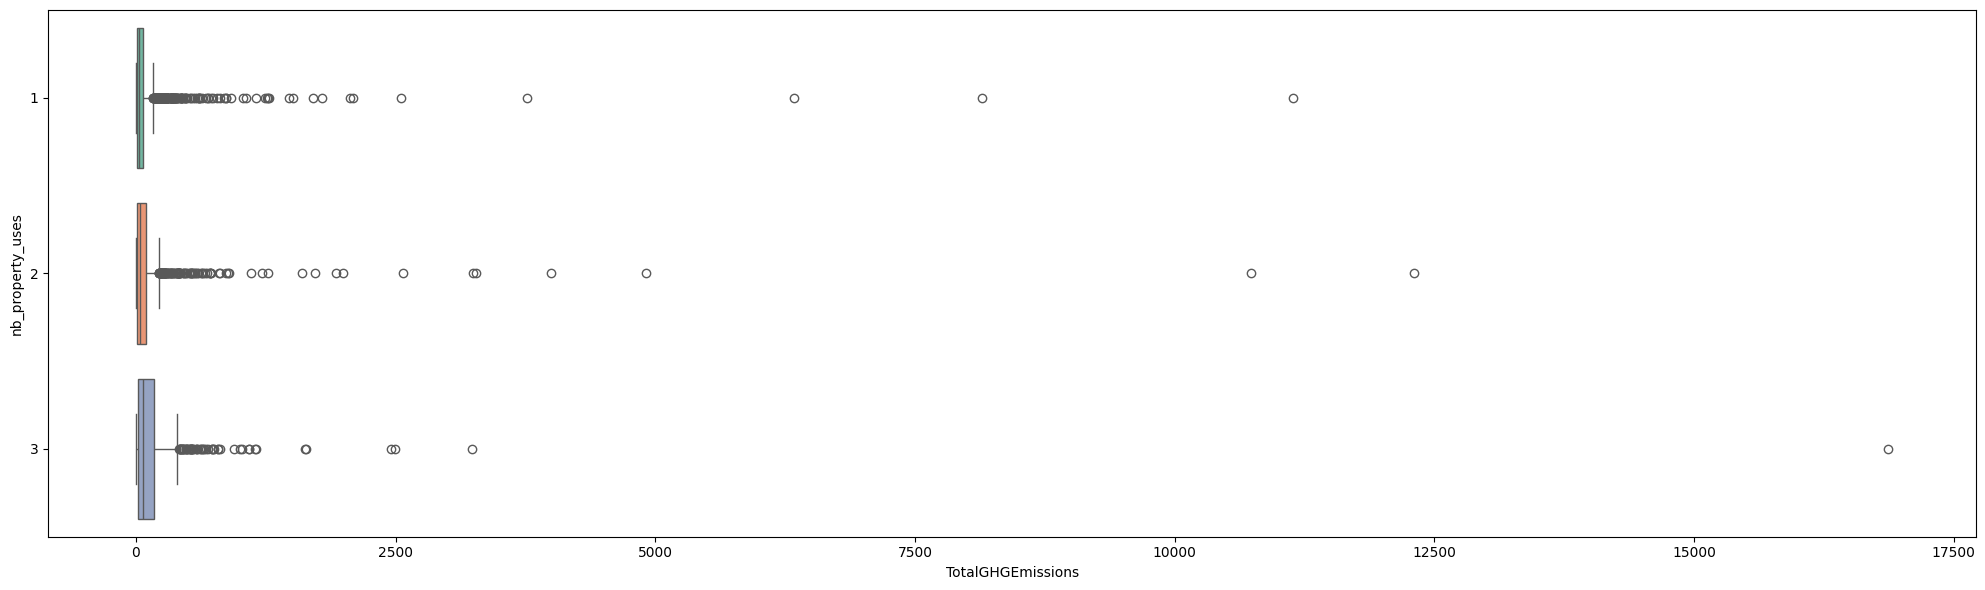

In [94]:
plt.figure(figsize=(20, 6))
data = df[df["nb_property_uses"] > 0]
sns.boxplot(y="nb_property_uses", x="TotalGHGEmissions", data=data, orient="h", palette='Set2')
plt.tight_layout()
plt.show()

In [95]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].mean()

nb_property_uses
0    65.84
1    94.06
2   124.97
3   183.40
Name: TotalGHGEmissions, dtype: float64

In [96]:
df.groupby("nb_property_uses")["TotalGHGEmissions"].median()

nb_property_uses
0   18.95
1   26.41
2   34.00
3   63.25
Name: TotalGHGEmissions, dtype: float64

#### Colonne ListOfAllPropertyUseTypes ✅ (création de nb_property_uses et is_mixed_use)

In [97]:
df["nb_property_uses"] = (
    df["ListOfAllPropertyUseTypes"]
    .fillna("")  # évite les erreurs sur NaN
    .apply(lambda x: len([u.strip() for u in x.split(",") if u.strip() != ""]))
)

In [98]:
df[["ListOfAllPropertyUseTypes", "nb_property_uses"]].head(10)

,ListOfAllPropertyUseTypes,nb_property_uses
0,Hotel,1
1,"Hotel, Parking, Restaurant",3
2,Hotel,1
3,Hotel,1
4,"Hotel, Parking, Swimming Pool",3
5,Police Station,1
6,Hotel,1
7,Other - Entertainment/Public Assembly,1
8,Hotel,1
9,Multifamily Housing,1


In [99]:
df["is_mixed_use"] = (df["nb_property_uses"] > 1).astype(int)

### Outliers

In [100]:
outliers, ratio = of.detect_outliers_iqr(df.select_dtypes(include="number"))

ratio.sort_values(ascending=False)

OSEBuildingID                     26.60
PropertyGFAParking                14.93
Electricity(kBtu)                 11.58
Electricity(kWh)                  11.58
SiteEnergyUse(kBtu)               11.34
SiteEnergyUseWN(kBtu)             11.29
PropertyGFATotal                  10.96
TotalGHGEmissions                 10.87
LargestPropertyUseTypeGFA         10.49
PropertyGFABuilding(s)            10.22
NaturalGas(therms)                 9.95
NaturalGas(kBtu)                   9.95
SourceEUI(kBtu/sf)                 8.95
SourceEUIWN(kBtu/sf)               8.74
SiteEUI(kBtu/sf)                   7.82
GHGEmissionsIntensity              7.79
SiteEUIWN(kBtu/sf)                 7.43
NumberofFloors                     7.11
nb_property_uses                   6.78
SecondLargestPropertyUseTypeGFA    6.10
NumberofBuildings                  5.72
SteamUse(kBtu)                     3.85
nb_certifications                  3.52
ZipCode                            3.38
primary_use_ratio                  2.75


### Supprimer les doublons 👥 

In [101]:
df.duplicated().sum()

np.int64(0)

### Suppression des lignes avec "DefaultData" = True et ComplianceStatus = "Compliant"

In [102]:
df["DefaultData"].value_counts(normalize=True)

DefaultData
False   0.97
True    0.03
Name: proportion, dtype: float64

In [103]:
df["ComplianceStatus"].value_counts(normalize=True)

ComplianceStatus
Compliant                      0.95
Error - Correct Default Data   0.03
Non-Compliant                  0.01
Missing Data                   0.00
Name: proportion, dtype: float64

In [104]:
df = df[df["DefaultData"] == False].copy()
df = df[df["ComplianceStatus"] == "Compliant"].copy()
df.drop(columns=["DefaultData","ComplianceStatus"])
df.shape, building_consumption.shape

((3211, 67), (3376, 46))

### Suppression des lignes avce des building hors "bâtiments non destinés à l’habitation"

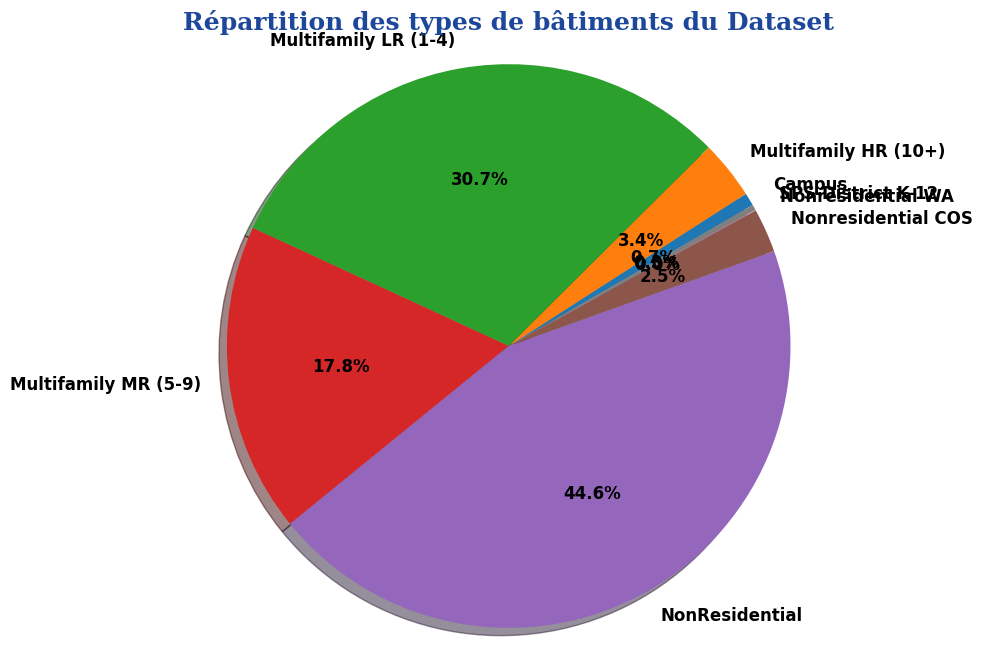

In [105]:
building_type = df.groupby(by='BuildingType')['OSEBuildingID'].nunique()

font_title = {'family': 'serif',
              'color':  '#1d479b',
              'weight': 'bold',
              'size': 18,
             }

fig, ax = plt.subplots(figsize=(8,8))
ax.pie(building_type.values, labels=building_type.index, 
       autopct='%1.1f%%', shadow=True, startangle=30,
       textprops=dict(color="black",size=12, weight="bold"))
ax.axis('equal')
ax.set_title("Répartition des types de bâtiments du Dataset", fontdict=font_title)
plt.show()

In [106]:
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

On constate qu'il y a certains doublons dans la colonne PrimaryPropertyType.

In [107]:
regex = re.compile(r'[\n\r\t]')
df['PrimaryPropertyType'] = (
    df['PrimaryPropertyType']
        .str.replace(r'[\n\r\t]', '', regex=True)
)
df.loc[(df['BuildingType']=="NonResidential"),'PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Small- and Mid-Sized Office    282
Other                          181
Warehouse                      178
Large Office                   164
Mixed Use Property             101
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             51
Supermarket / Grocery Store     40
K-12 School                     38
Medical Office                  38
Self-Storage Facility           28
Residence Hall                  21
Senior Care Community           20
University                      17
Refrigerated Warehouse          12
Restaurant                      11
Hospital                        10
Laboratory                      10
Low-Rise Multifamily             1
Name: count, dtype: int64

In [108]:
val = [
    'NonResidential',
    'Nonresidential COS',
   "Campus",
    "Nonresidential WA",
    "'SPS-District K-12'"
]

df = df[df["BuildingType"].isin(val)]

### Suppresion des lignes avec des Outliers 

In [109]:
df = df[~df["Outlier"].isnull() == False]
df.drop('Outlier', axis=1, inplace=True)

### Suppression des colonnes avec toujours la même valeurs

In [110]:
df.loc[:, df.nunique() == 1]

,DataYear,City,State,DefaultData,ComplianceStatus
0,2016,Seattle,WA,False,Compliant
1,2016,Seattle,WA,False,Compliant
2,2016,Seattle,WA,False,Compliant
3,2016,Seattle,WA,False,Compliant
4,2016,Seattle,WA,False,Compliant
...,...,...,...,...,...
3370,2016,Seattle,WA,False,Compliant
3372,2016,Seattle,WA,False,Compliant
3373,2016,Seattle,WA,False,Compliant
3374,2016,Seattle,WA,False,Compliant


In [111]:
df = df.loc[:, df.nunique() > 1]

### Suppression des variables redondantes

In [112]:
redundant_features = ['NaturalGas(therms)','Electricity(kWh)']
df.drop(redundant_features, axis=1, inplace=True)

In [113]:
df.sample(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use
225,349,NonResidential,Large Office,2nd and Seneca,1191 2nd Avenue,"98,101.00",0942000030,7,DOWNTOWN,47.61,-122.34,1991,1.00,29,635303,197231,438072,"Office, Parking",Office,"522,667.00",Parking,"194,435.00",Convenience Store without Gas Station,"6,122.00",95.00,34.90,35.90,108.80,111.90,"18,221,224.00","18,754,466.00","180,731.80","18,040,489.00",0.00,139.72,0.22,1,0,0,0,0,0,0,1,0,1,1,1,0,1,1,1,1,0,9,2000,2,0.82,1
144,232,NonResidential,Hotel,Silver Cloud Inn,1150 Fairview Ave N,"98,109.00",4088802955,3,LAKE UNION,47.63,-122.33,1998,1.00,5,123920,30000,93920,"Hotel, Parking, Swimming Pool",Hotel,"123,920.00",Parking,"30,000.00",Swimming Pool,0.00,79.00,75.60,78.10,148.20,152.20,"9,373,179.00","9,676,783.00",0.00,"4,079,217.00","5,293,961.00",309.60,2.50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,3,1.00,1
1648,22962,NonResidential,Small- and Mid-Sized Office,Northgate Meridian Bldg,2111 N Northgate Way,"98,133.00",2926049094,5,NORTHWEST,47.71,-122.33,1987,1.00,3,76105,27307,48798,Office,Office,"76,105.00",NaN,NaN,NaN,NaN,91.00,32.50,34.10,102.00,107.10,"2,472,350.25","2,596,383.25",0.00,"2,472,350.00",0.00,17.24,0.23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1.00,0
1436,21794,NonResidential,K-12 School,Peyton,2400 11th Ave East,"98,102.00",2025049007,3,EAST,47.64,-122.32,1968,1.00,5,43594,0,43594,K-12 School,K-12 School,"40,809.00",NaN,NaN,NaN,NaN,38.00,60.70,66.20,128.50,134.20,"2,478,045.50","2,699,616.00",0.00,"1,264,732.00","1,213,313.00",73.26,1.68,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,0.94,0
1331,21537,NonResidential,Hotel,Seattle Pacific Hotel,325 Aurora Ave N,"98,109.00",1991200800,7,LAKE UNION,47.62,-122.34,1961,1.00,3,29186,4256,24930,Hotel,Hotel,"19,000.00",NaN,NaN,NaN,NaN,95.00,45.60,45.60,85.70,85.70,"867,184.38","867,184.38",0.00,"343,234.00","523,951.00",30.22,1.04,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,0.65,0


### Suppresion des colonnes WN

Les suffixes WN : "Weather Normalized" - Ce sont les mesures normalisées avec les conditions climatiques. Dans le cadre de notre analyse, la météo ne rentrera pas en compte.

In [114]:
def search_componant(df, suffix=None):
  componant = []
  for col in df.columns:
      if suffix in col: 
        componant.append(col)
  return componant

In [115]:
df.drop(search_componant(df,'WN'), axis=1, inplace=True)

## Analyse univariée

In [116]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OSEBuildingID,"1,538.00","16,527.60","13,835.26",1.00,604.25,"21,182.50","24,619.00","50,226.00"
ZipCode,"1,525.00","98,116.66",18.56,"98,006.00","98,104.00","98,109.00","98,125.00","98,199.00"
CouncilDistrictCode,"1,538.00",4.41,2.19,1.00,2.00,4.00,7.00,7.00
Latitude,"1,538.00",47.62,0.05,47.51,47.59,47.61,47.65,47.73
Longitude,"1,538.00",-122.33,0.02,-122.41,-122.34,-122.33,-122.32,-122.26
YearBuilt,"1,538.00","1,961.54",32.87,"1,900.00","1,930.00","1,965.00","1,988.00","2,015.00"
NumberofBuildings,"1,538.00",1.18,3.05,0.00,1.00,1.00,1.00,111.00
NumberofFloors,"1,538.00",4.29,6.80,0.00,1.00,2.00,4.00,99.00
PropertyGFATotal,"1,538.00","121,122.57","307,114.22","11,285.00","28,811.00","48,013.00","106,030.75","9,320,156.00"
PropertyGFAParking,"1,538.00","13,932.34","43,849.52",0.00,0.00,0.00,0.00,"512,608.00"


### Colonnes numérique ALL

In [117]:
data = df.select_dtypes(include="number").copy()

In [118]:
cols_to_drop = [
    "OSEBuildingID", "ZipCode","CouncilDistrictCode",
    "Latitude","Longitude","YearBuilt",
    '2000','2001','2002','2003','2004','2005','2006','2007',
    '2008','2009','2010','2011','2012','2013','2014','2015',
    '2016','2017','is_mixed_use','nb_certifications',"nb_property_uses","NumberofBuildings","NumberofFloors"
]

data = data.drop(columns=cols_to_drop)

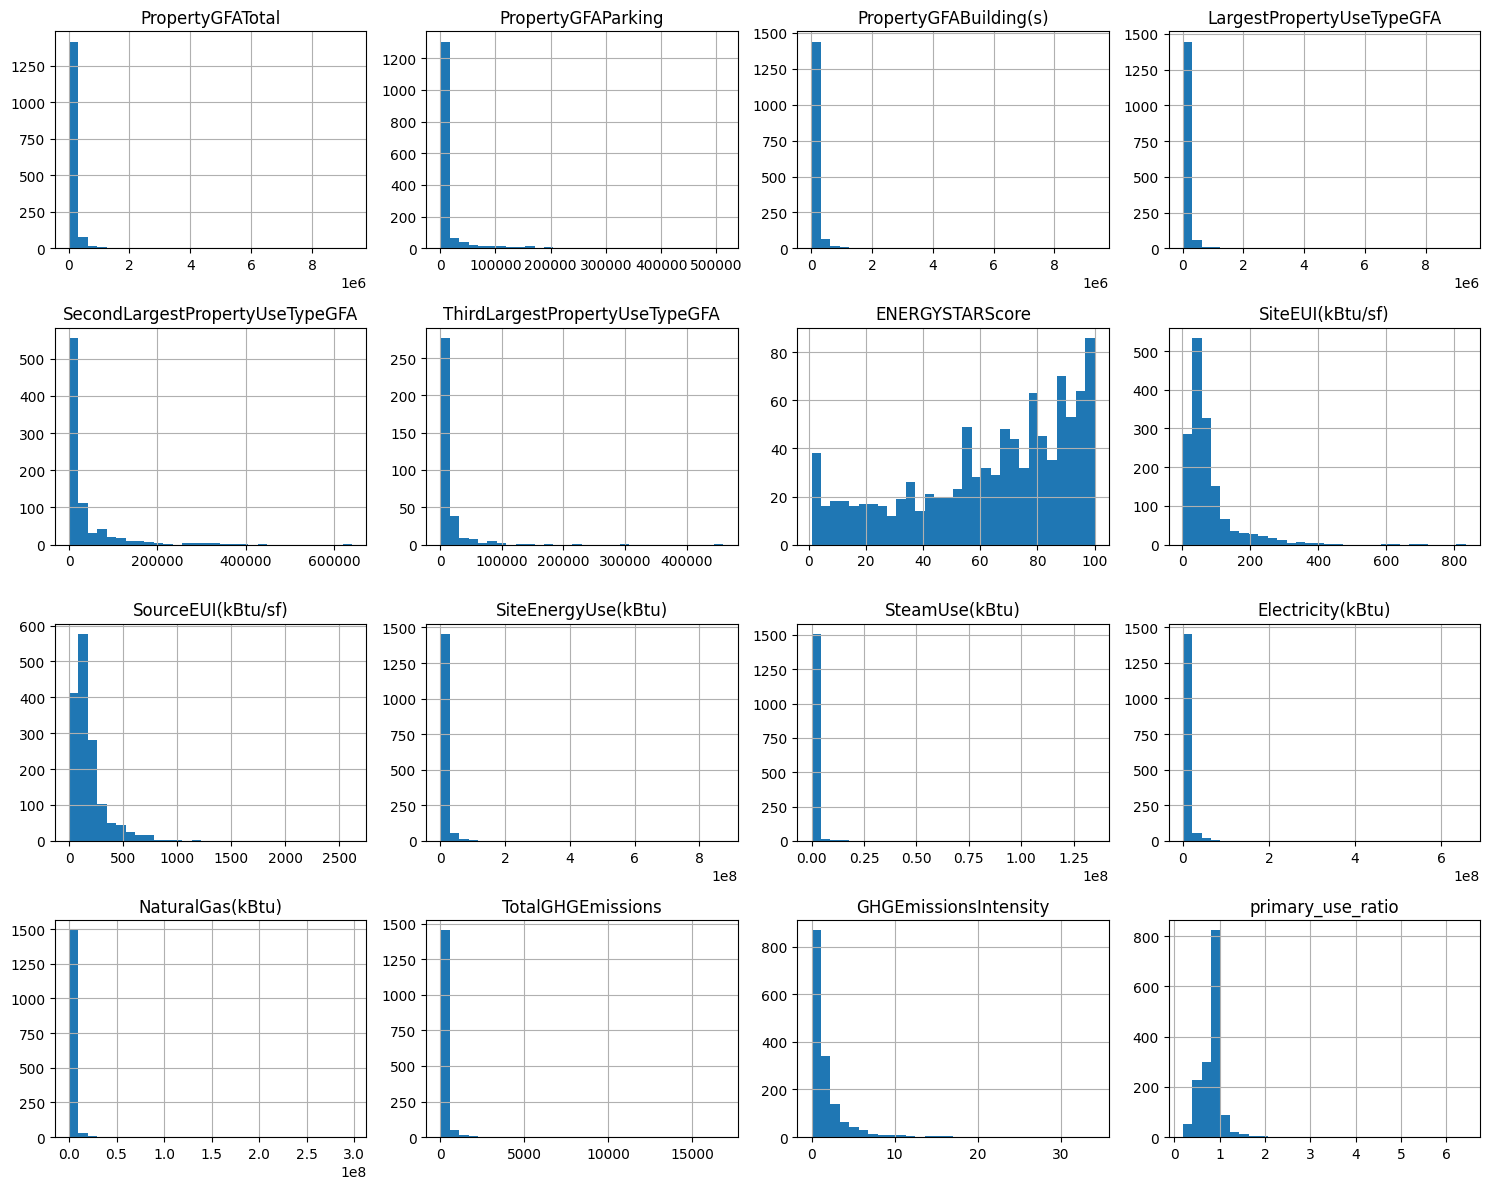

In [119]:
data.hist(bins=30, figsize=(15,12))
plt.tight_layout()
plt.show()

In [120]:
data.skew().sort_values(ascending=False) # asymértie des données sur la droite (sauf ENERGYSTARScore) ==> normaliser les données pour avoir une meilleure distribution

LargestPropertyUseTypeGFA         22.74
NaturalGas(kBtu)                  21.30
PropertyGFABuilding(s)            21.28
Electricity(kBtu)                 20.18
PropertyGFATotal                  18.79
SteamUse(kBtu)                    18.39
SiteEnergyUse(kBtu)               17.42
TotalGHGEmissions                 13.68
ThirdLargestPropertyUseTypeGFA     7.57
primary_use_ratio                  5.85
PropertyGFAParking                 5.01
SourceEUI(kBtu/sf)                 4.94
GHGEmissionsIntensity              4.55
SecondLargestPropertyUseTypeGFA    3.76
SiteEUI(kBtu/sf)                   3.68
ENERGYSTARScore                   -0.66
dtype: float64

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


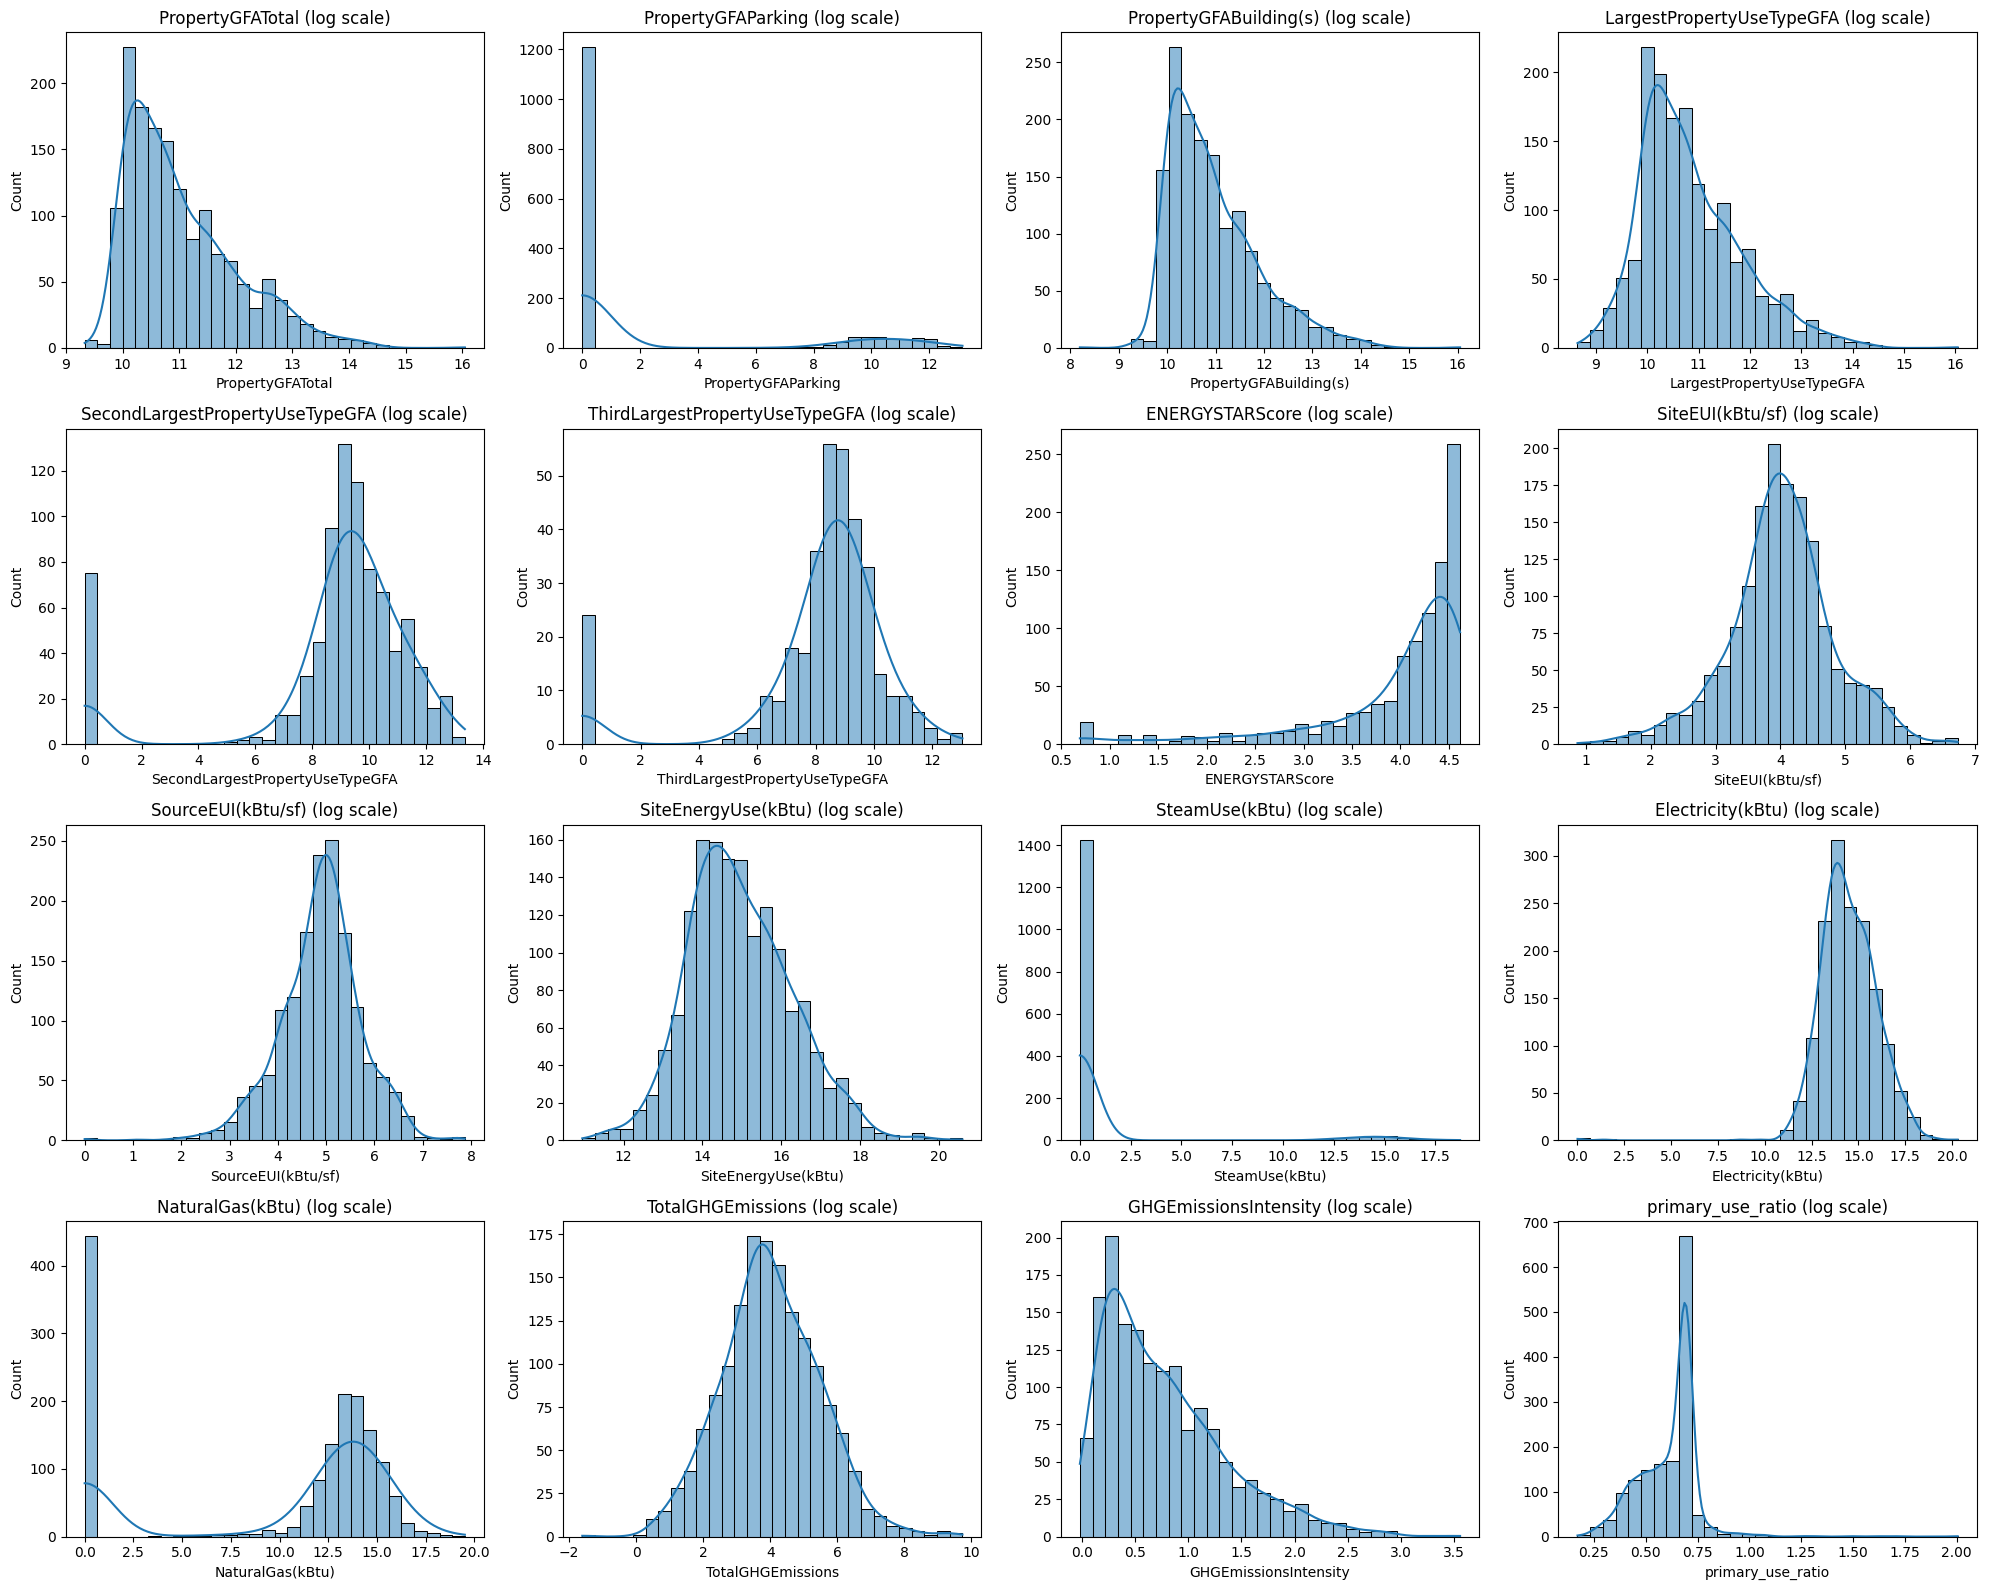

In [121]:
cols = data.columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cols):
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log scale)")

# Supprimer les axes vides si nombre impair
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Ca fait beaucoup de données. Je vais concentrer mon analyse univariée sur quelques indicateurs :

🌡 Intensités énergétiques

- SiteEnergyUse(kBtu) : Intensité énergétique du bâtiment

- SiteEUI(kBtu/sf) : Intensité énergétique par surface 

- SourceEUI(kBtu/sf) :  Intensité énergie primaire source ((énergie nécessaire pour produire et transporter cette énergie))

🌱 Émissions carbone

- TotalGHGEmissions : quantité totales de gaz à effet de serre émise par bâtiment (tonnes métriques CO₂e).

- GHGEmissionsIntensity : Émissions rapportées à la surface du bâtiment (TotalGHGEmissions/PropertyGFATotal)

⭐ Performance énergétique

- ENERGYSTARScore : Score Energy Star (1-100)

🧾 Informations 

- PropertyGFATotal : Surface totale brute (Gross Floor Area) en pieds carrés.



### Colonnes numériques sélectionnées

In [122]:
col_sel = [
    "SiteEnergyUse(kBtu)",
    "SiteEUI(kBtu/sf)",
    "SourceEUI(kBtu/sf)",
    "TotalGHGEmissions",
    "GHGEmissionsIntensity",
    "ENERGYSTARScore",
    "PropertyGFATotal"
]

In [123]:
data = df[col_sel].copy()

In [124]:
data.skew() # Toutes valeurs des colonnes ont un skewness > 0. Ce qui signifie est asymétrique à gauche. 
# Pour avoir une meilleure visualisation, je vais log les données.

SiteEnergyUse(kBtu)     17.42
SiteEUI(kBtu/sf)         3.68
SourceEUI(kBtu/sf)       4.94
TotalGHGEmissions       13.68
GHGEmissionsIntensity    4.55
ENERGYSTARScore         -0.66
PropertyGFATotal        18.79
dtype: float64

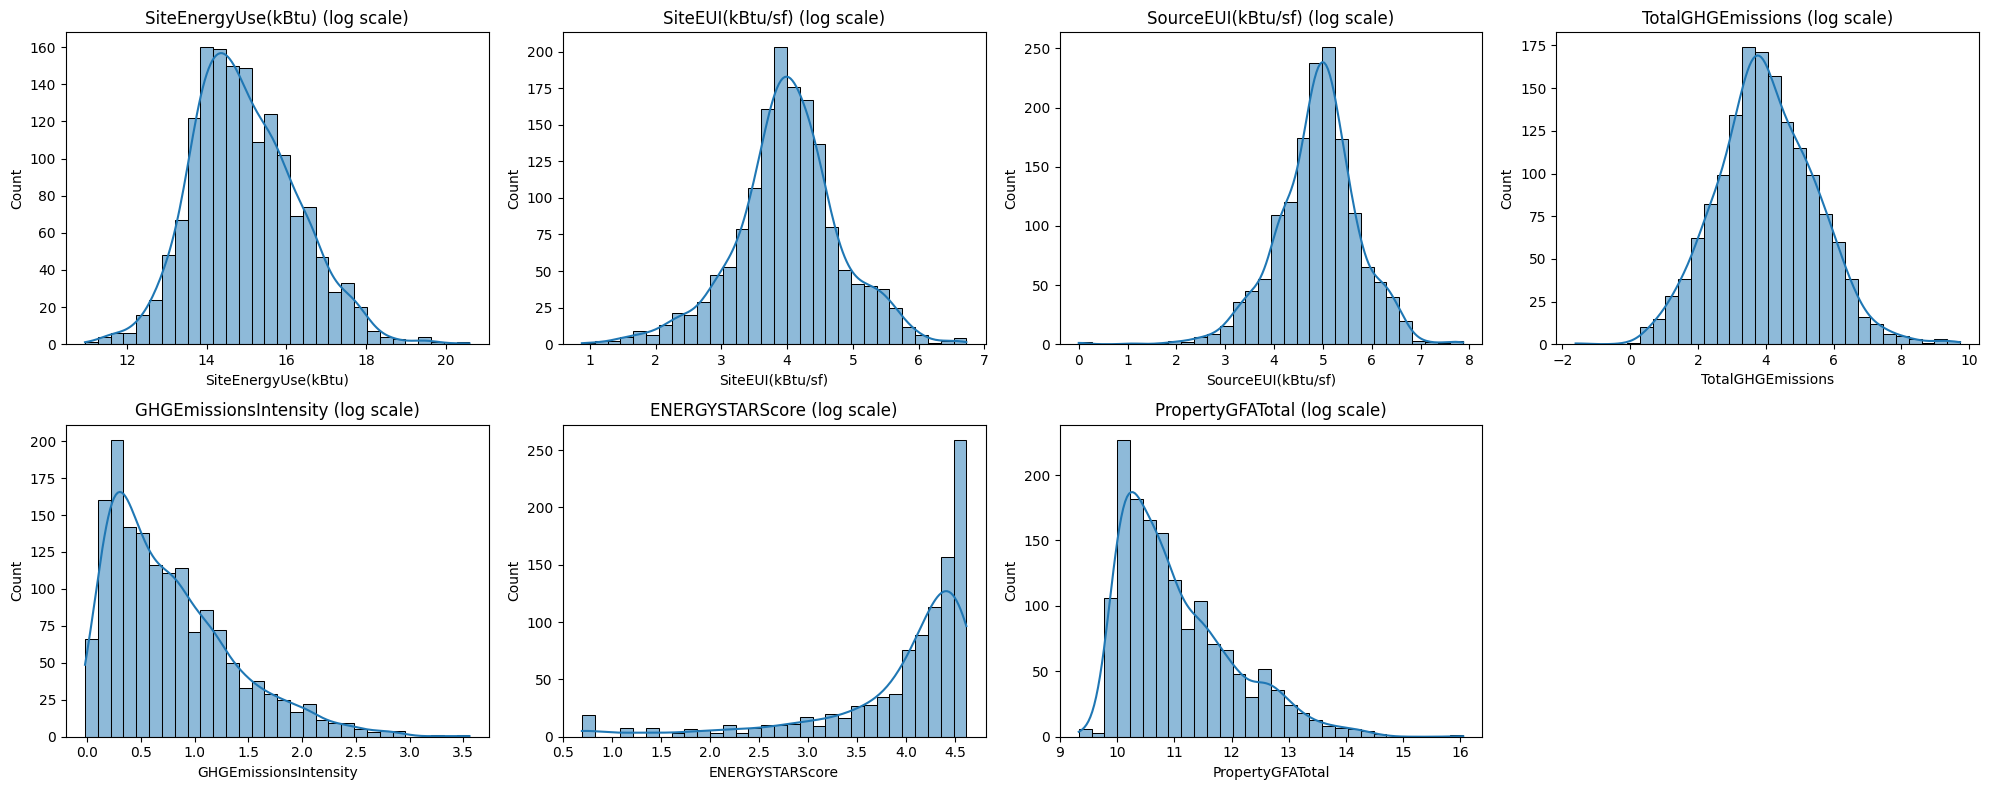

In [125]:
cols = data.columns
n_cols = 4
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))

axes = axes.flatten()  # pour itérer facilement

for i, col in enumerate(cols):
    sns.histplot(np.log1p(data[col]), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"{col} (log scale)")

# Supprimer les axes vides si nombre impair
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

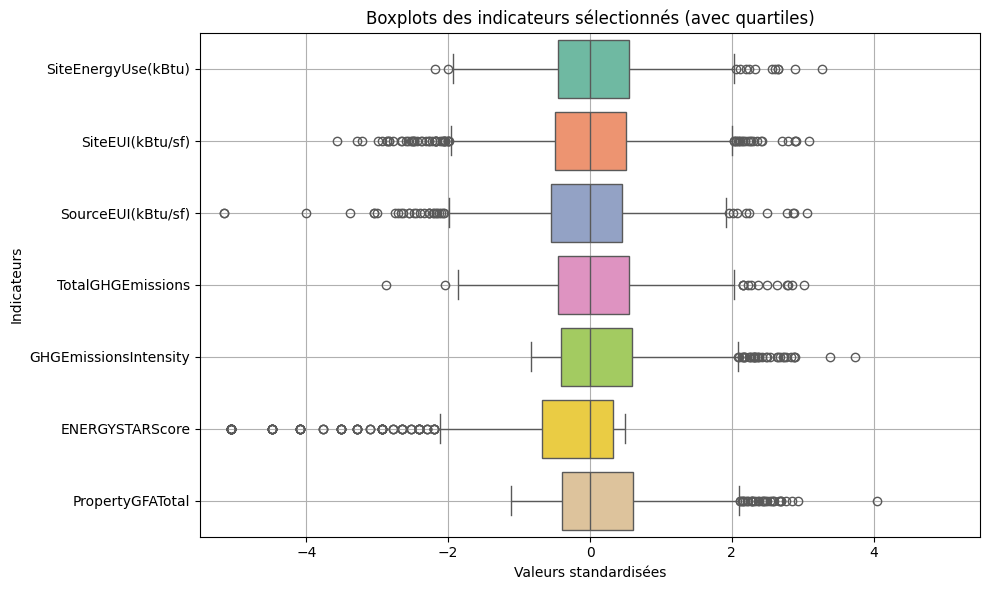

In [126]:
data_log = np.log1p(data)

data_scaled = pd.DataFrame(
    RobustScaler().fit_transform(data_log),
    columns=data.columns
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=data_scaled,
    orient="h",
    palette="Set2",
    saturation=0.8
)

plt.title("Boxplots des indicateurs sélectionnés (avec quartiles)")
plt.ylabel("Indicateurs")
plt.xlabel("Valeurs standardisées")
plt.xlim(-5.5, 5.5)
plt.grid(True)
plt.tight_layout()
plt.show()


Les consommations et émissions sont fortement concentrées sur un petit nombre de bâtiments.

In [127]:
outliers, ratio = of.detect_outliers_iqr(data)

ratio.sort_values(ascending=False)

PropertyGFATotal        12.48
SiteEnergyUse(kBtu)     11.38
TotalGHGEmissions       10.92
SiteEUI(kBtu/sf)         9.43
GHGEmissionsIntensity    8.71
SourceEUI(kBtu/sf)       7.93
ENERGYSTARScore          0.00
dtype: float64

### Colonnes catégorielles ALL

In [128]:
cat_cols = [
       'PrimaryPropertyType', 'PropertyName', 'Address',
       'TaxParcelIdentificationNumber', 'Neighborhood',
       'ListOfAllPropertyUseTypes', 'LargestPropertyUseType',
       'SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType',
       'first_cert_year',
       'is_mixed_use','nb_certifications',"nb_property_uses","NumberofBuildings","NumberofFloors"
]

In [129]:
# Nombre de modalités
for col in cat_cols:
    print(col, ":", df[col].nunique())

PrimaryPropertyType : 21
PropertyName : 1534
Address : 1517
TaxParcelIdentificationNumber : 1458
Neighborhood : 19
ListOfAllPropertyUseTypes : 369
LargestPropertyUseType : 55
SecondLargestPropertyUseType : 47
ThirdLargestPropertyUseType : 39
first_cert_year : 16
is_mixed_use : 2
nb_certifications : 13
nb_property_uses : 11
NumberofBuildings : 16
NumberofFloors : 45


In [130]:
# Distribution brute
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 PrimaryPropertyType
PrimaryPropertyType
Small- and Mid-Sized Office    286
Other                          243
Warehouse                      185
Large Office                   169
Mixed Use Property             113
Retail Store                    85
Hotel                           75
Worship Facility                69
Distribution Center             53
K-12 School                     42
Name: count, dtype: int64

 PropertyName
PropertyName
South Park                     2
Canal Building                 2
Bayview Building               2
Airport Way                    2
Mayflower park hotel           1
Paramount Hotel                1
5673-The Westin Seattle        1
HOTEL MAX                      1
WARWICK SEATTLE HOTEL (ID8)    1
West Precinct                  1
Name: count, dtype: int64

 Address
Address
2600 SW Barton St              4
2203 Airport Way S             4
309 South Cloverdale Street    4
500 5TH AVE                    2
3613 4th Ave S                 2
516 1st Ave W  

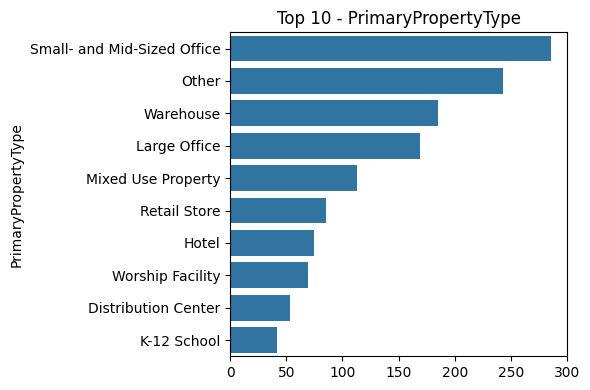

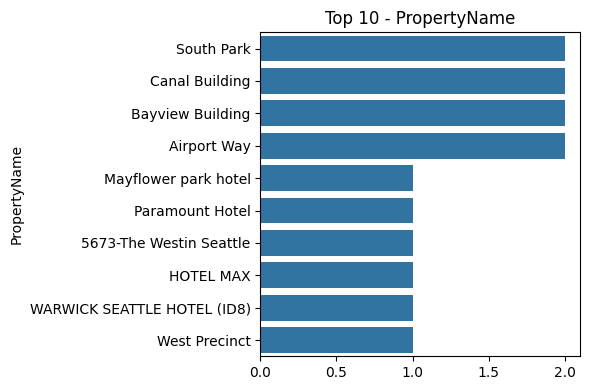

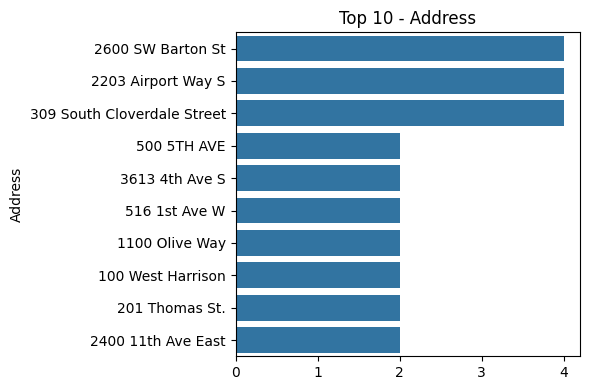

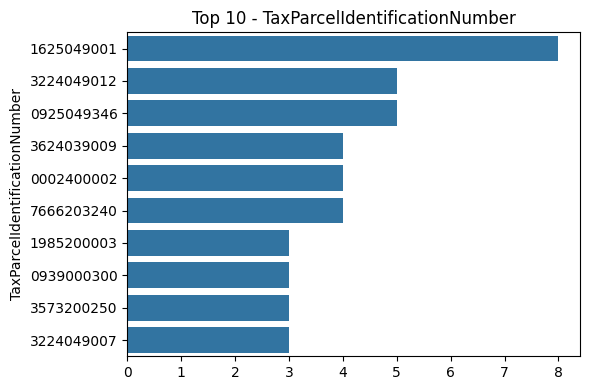

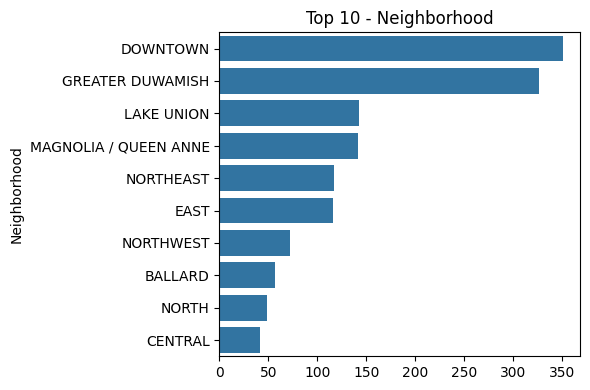

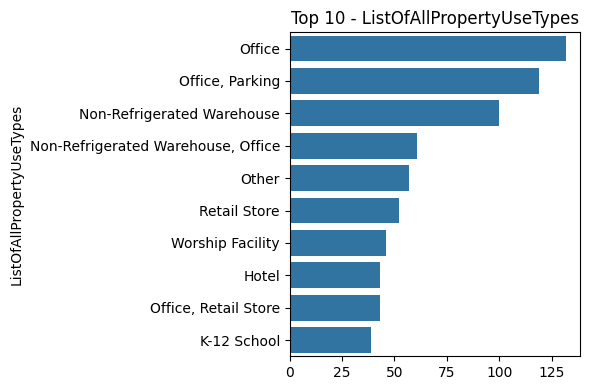

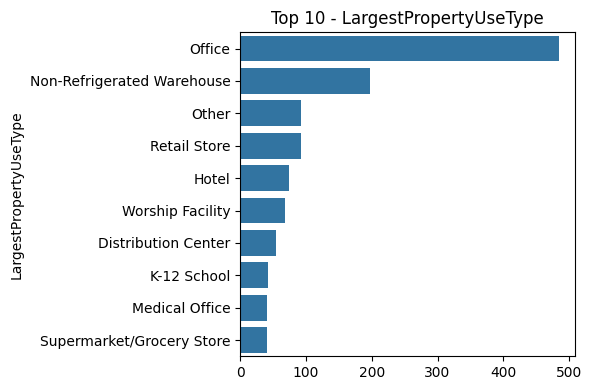

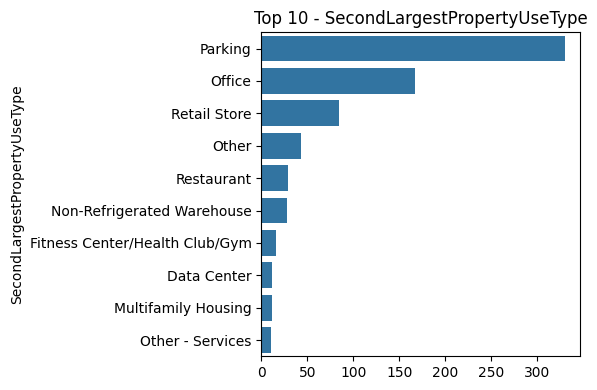

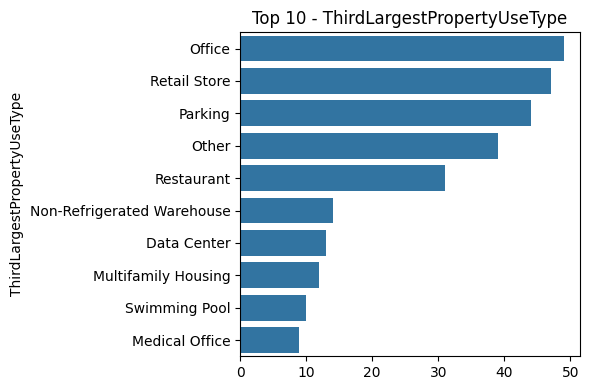

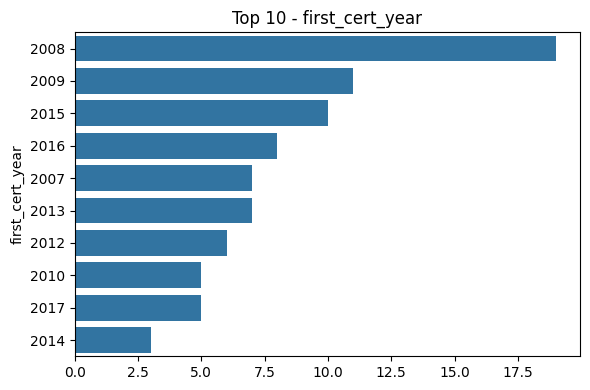

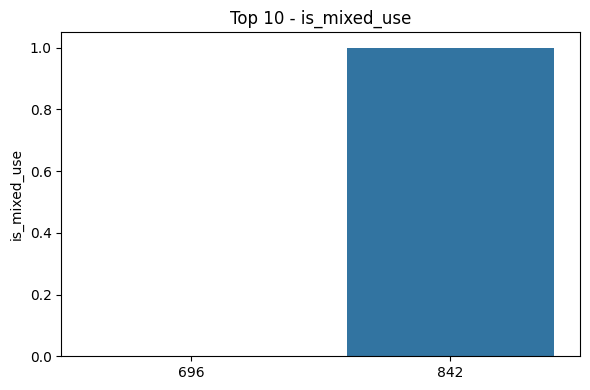

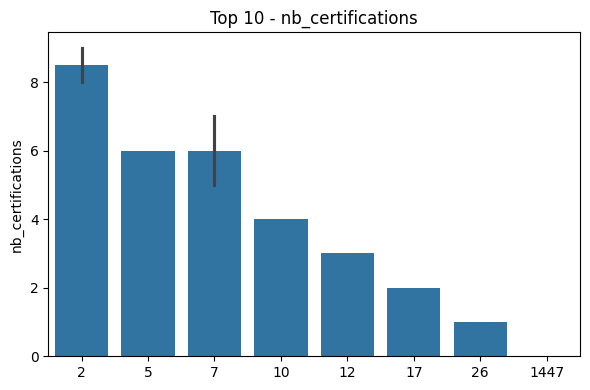

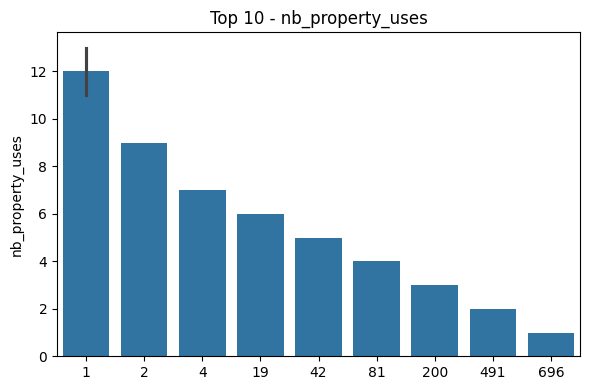

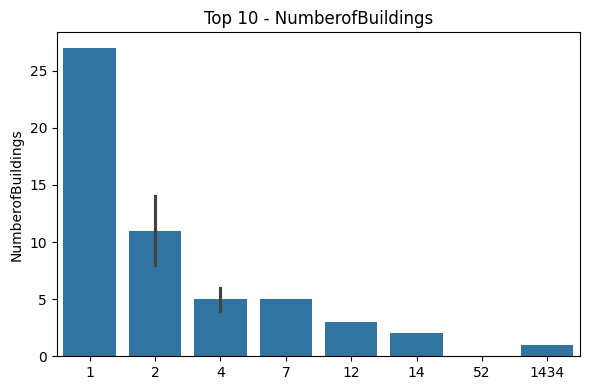

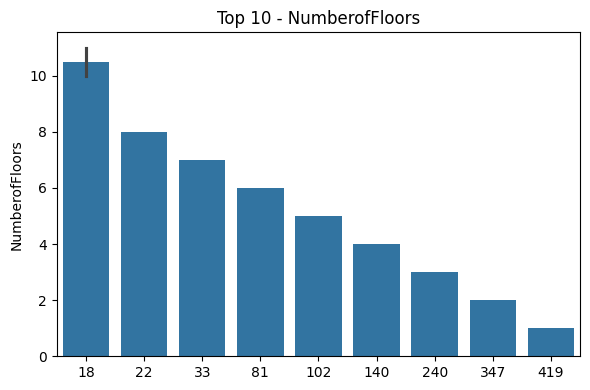

In [131]:
for col in cat_cols:
    
    plt.figure(figsize=(6,4))
    
    top_categories = df[col].value_counts().nlargest(10)
    
    sns.barplot(
        x=top_categories.values,
        y=top_categories.index
    )
    
    plt.title(f"Top 10 - {col}")
    plt.tight_layout()
    plt.show()

## Analyse bivariée

In [132]:
col_sel

['SiteEnergyUse(kBtu)',
 'SiteEUI(kBtu/sf)',
 'SourceEUI(kBtu/sf)',
 'TotalGHGEmissions',
 'GHGEmissionsIntensity',
 'ENERGYSTARScore',
 'PropertyGFATotal']

In [133]:
df.sample(5)

,OSEBuildingID,BuildingType,PrimaryPropertyType,PropertyName,Address,ZipCode,TaxParcelIdentificationNumber,CouncilDistrictCode,Neighborhood,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),ListOfAllPropertyUseTypes,LargestPropertyUseType,LargestPropertyUseTypeGFA,SecondLargestPropertyUseType,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),TotalGHGEmissions,GHGEmissionsIntensity,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,nb_certifications,first_cert_year,nb_property_uses,primary_use_ratio,is_mixed_use
2996,27821,NonResidential,Supermarket / Grocery Store,70500866 -- Northgate,11100 Roosevelt Way NE,"98,125.00",5724500615,5,North,47.71,-122.32,1996,1.00,1,44755,0,44755,Supermarket/Grocery Store,Supermarket/Grocery Store,"46,978.00",NaN,NaN,NaN,NaN,56.00,245.20,521.00,"11,521,140.00",0.00,"5,923,610.00","5,597,529.00",338.58,7.57,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1.05,0
313,446,NonResidential,Distribution Center,Washington State Ferries Building,6000 6th Ave S,"98,108.00",2024049060,2,GREATER DUWAMISH,47.55,-122.33,1963,1.00,1,59090,0,59090,"Distribution Center, Office",Distribution Center,"40,272.00",Office,"18,818.00",NaN,NaN,45.00,46.60,71.40,"2,756,214.75",0.00,"634,386.00","2,121,829.00",117.11,1.98,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,2,0.68,1
410,569,NonResidential,Mixed Use Property,Pacific Tower,1200 12th Avenue South,"98,144.00",2829600110,2,GREATER DUWAMISH,47.59,-122.32,1932,1.00,14,304052,0,304052,"Medical Office, Office, Parking",Office,"218,918.00",Parking,"156,487.00",Medical Office,"84,051.90",66.00,69.40,202.90,"21,027,396.00",0.00,"18,843,504.00","2,183,891.00",247.35,0.81,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,2,2008,3,0.72,1
2104,24484,NonResidential,Worship Facility,Messiah Lutheran Church,7050 35th NE,"98,115.00",7974200451,4,NORTHEAST,47.68,-122.29,1950,1.00,2,20385,0,20385,Worship Facility,Worship Facility,"20,385.00",NaN,NaN,NaN,NaN,65.00,39.70,61.60,"809,291.81",0.00,"193,858.00","615,434.00",34.04,1.67,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1.00,0
1030,20552,NonResidential,Retail Store,OLD WESTERN STEEL CASTING CO,3300 1ST AVE S,"98,134.00",1327300008,2,GREATER DUWAMISH,47.57,-122.33,1914,1.00,1,20000,0,20000,Retail Store,Retail Store,"20,000.00",NaN,NaN,NaN,NaN,75.00,27.90,87.60,"557,863.69",0.00,"557,864.00",0.00,3.89,0.19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,1,1.00,0


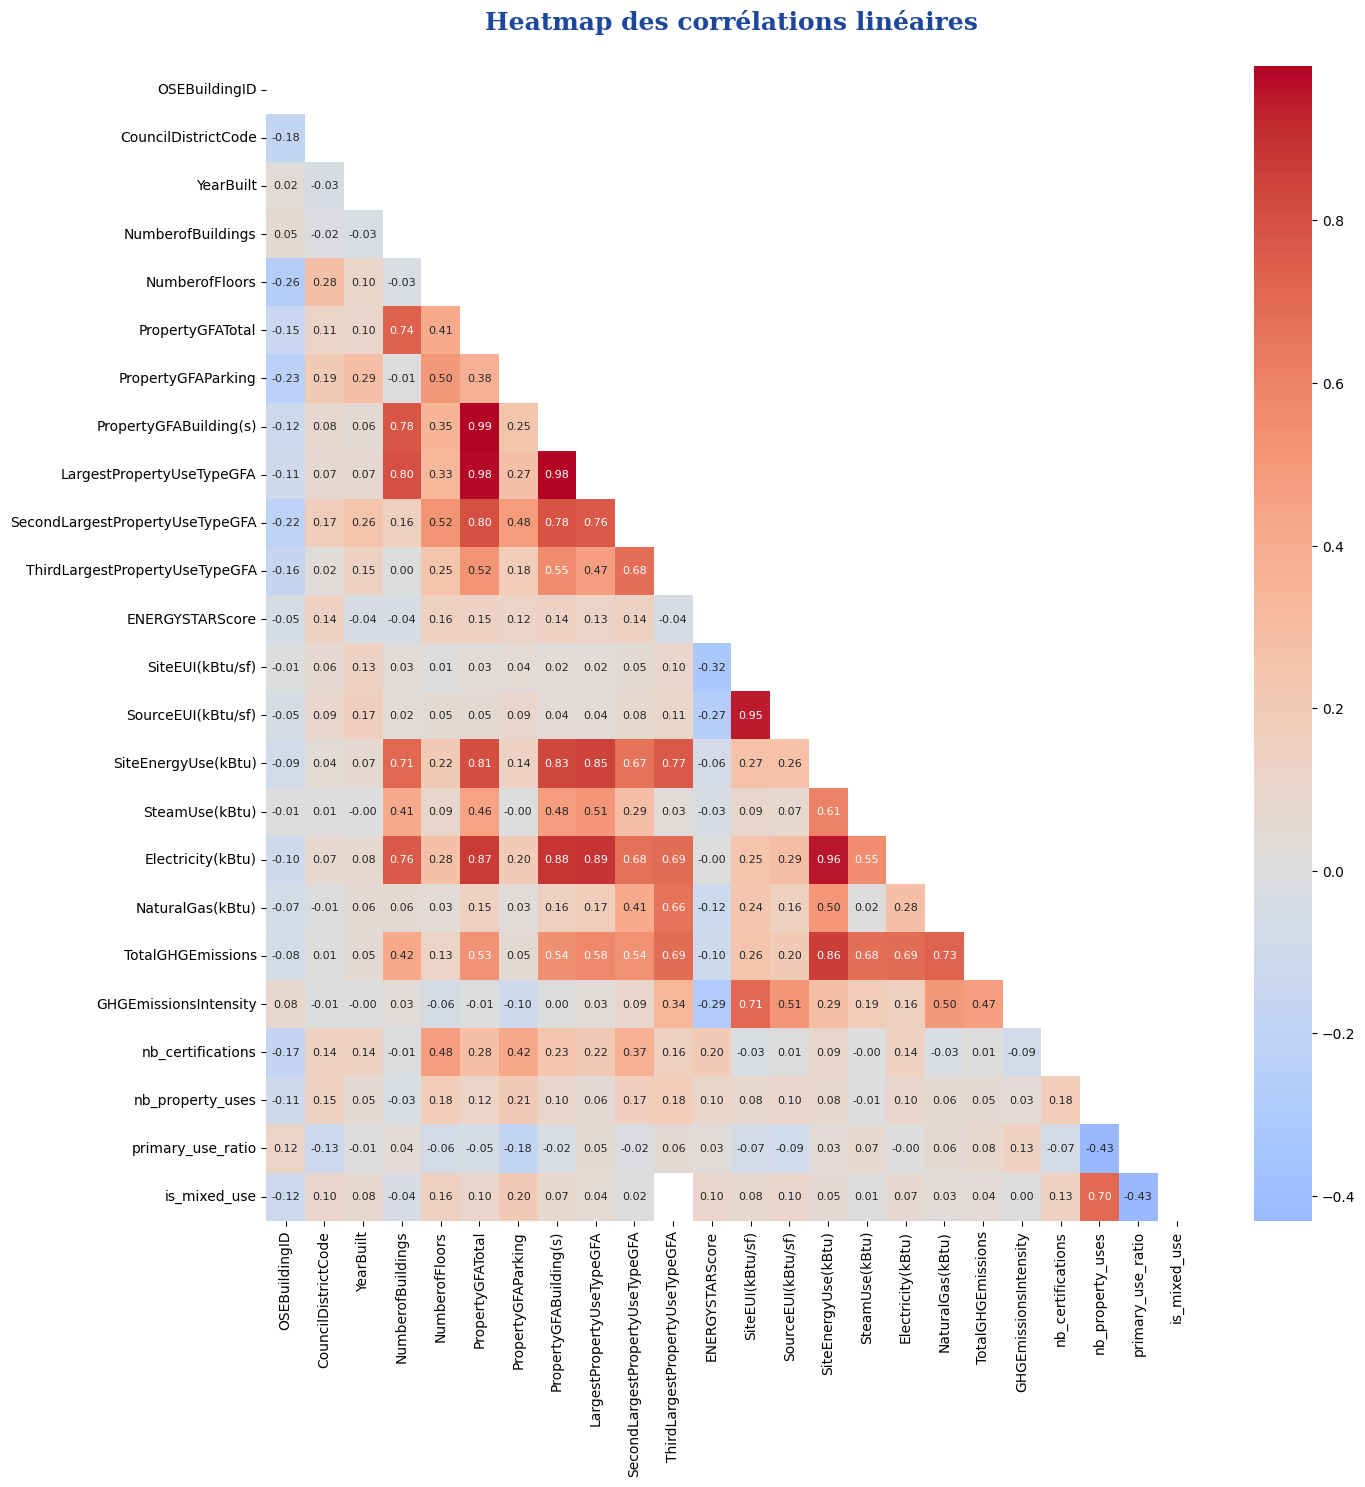

In [134]:
data = df.select_dtypes(include="number")
data.drop(columns=['2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017','ZipCode',"Latitude","Longitude"],inplace=True)

corr = data.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
fig, ax = plt.subplots(figsize=(15,15))
ax = sns.heatmap(corr, annot=True, fmt=".2f", annot_kws={'size':8}, 
                 mask=mask, center=0, cmap="coolwarm")
plt.title(f"Heatmap des corrélations linéaires\n", 
          fontdict=font_title)
plt.show()

/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/Users/maximebarbier/Documents/00 - Repositories/building-energy-Seattle/.venv/lib/python3.11/site-packages/dython/nominal.py:161: RuntimeWarning: Unable to calculate Cramer's V using bias correction. Consider using bias_correction=False (or cramers_v_bias_correction=False if calling from associations)
  warnings.warn(
/Users/maximebarbier/Documents/00 - R

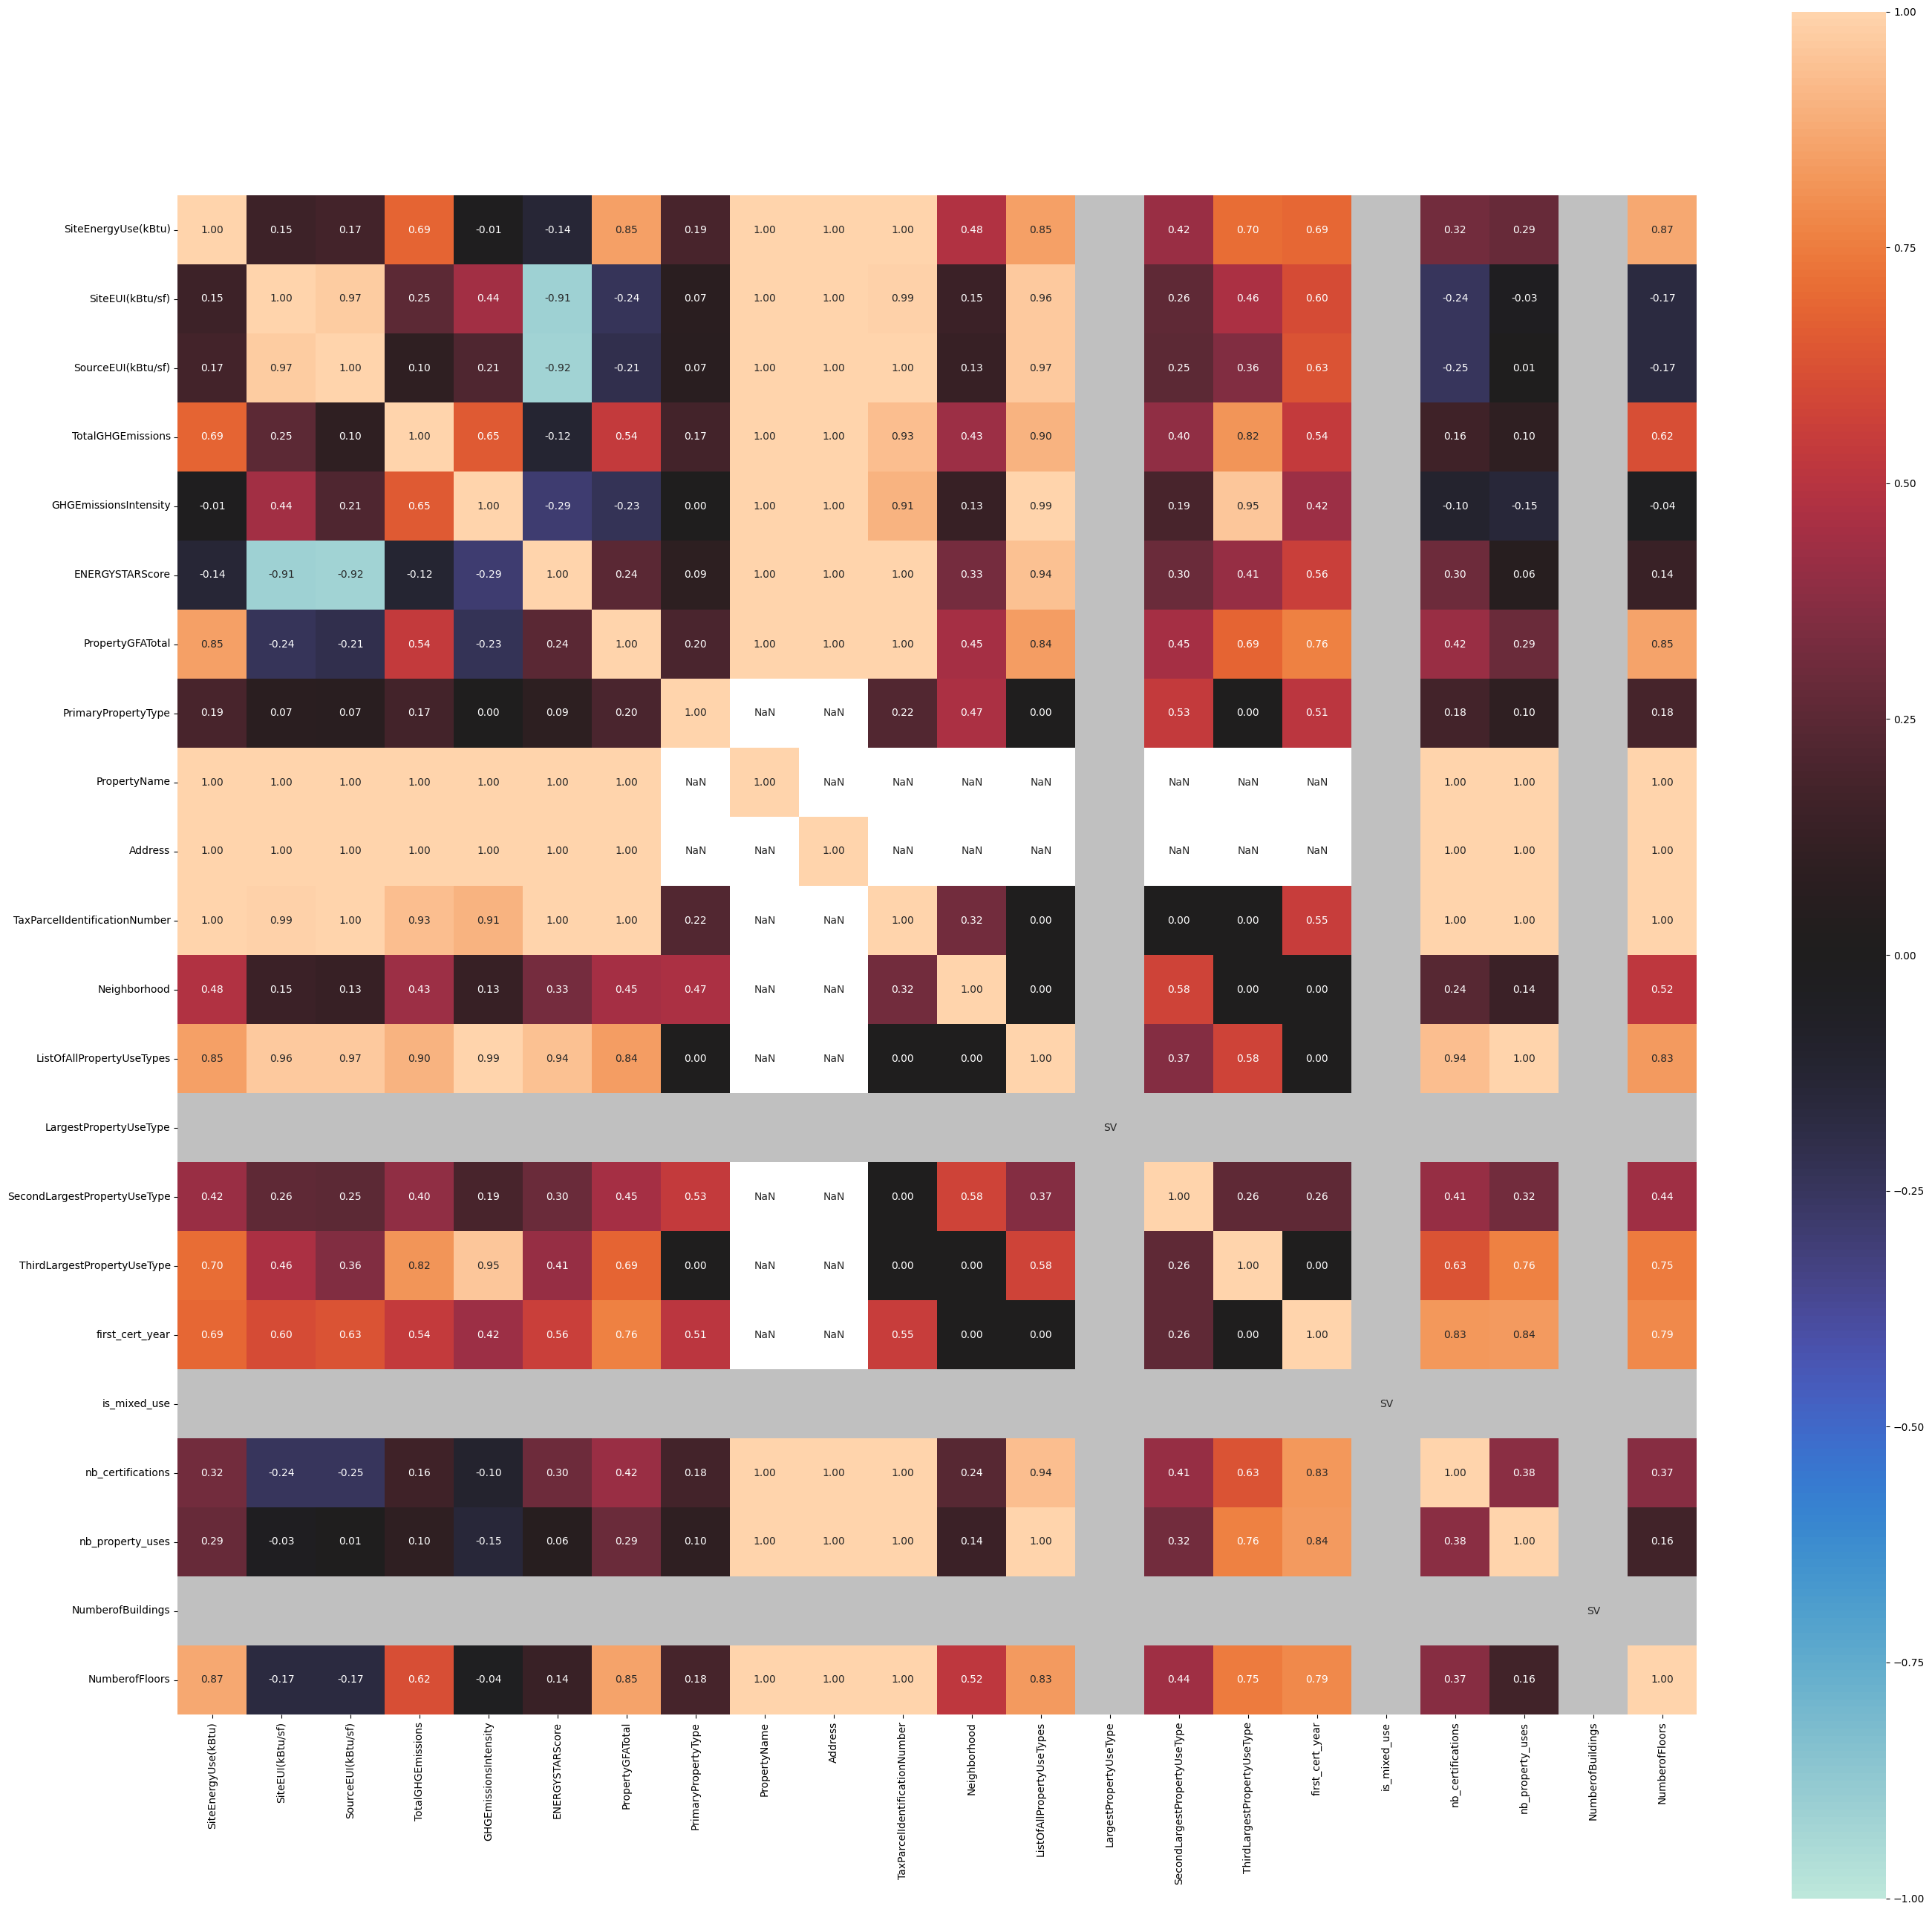

In [135]:
# Créer une copie du DataFrame sans NaN
df_clean = df[
    col_sel + cat_cols
].copy()

# Supprimer toutes les lignes avec au moins un NaN
df_clean = df_clean.dropna()

cols_cat = df_clean[ col_sel + cat_cols ].columns.tolist()

# Puis appliquer associations
cols_cat = df_clean.select_dtypes(include=['object', 'category', 'string', 'bool']).columns.tolist()
results = associations(df_clean, nominal_columns=cols_cat, plot=True)

### Colonne numériques selectionnées

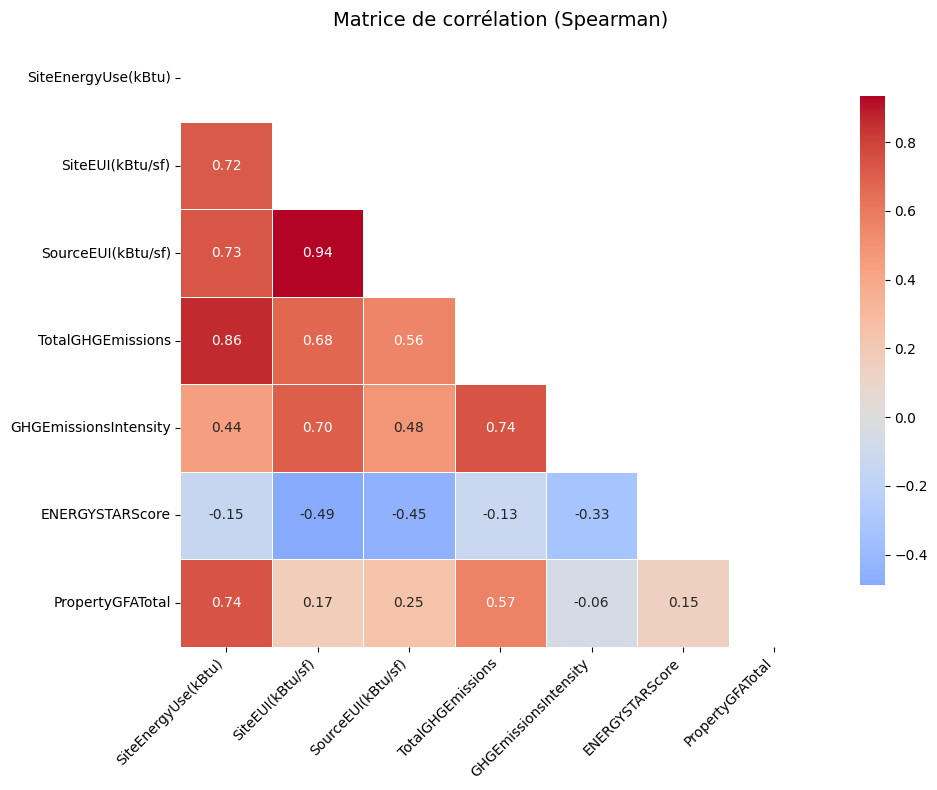

In [136]:
data = df[col_sel]

corr_matrix = data.corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice de corrélation (Spearman)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Colonne "SiteEUIWN(kBtu/sf)" (target 1 potentielle)

#### Conso d'energie vs carctéristique principale

In [139]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "BuildingType")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × BuildingType
Test          : Kruskal-Wallis (BuildingType → TotalGHGEmissions)
Observations  : 1537/1538 (0 manquantes)
Groupes       : 3

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.023

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'BuildingType',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (BuildingType → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.023,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1537,
 'n_missing': np.int64(0),
 'k_groups': 3,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

Bien que le type de bâtiment soit associé de manière significative à l’intensité énergétique (p < 0.001), la taille d’effet reste faible (η² = 0.023). Cela indique que la classification administrative du bâtiment explique peu la variabilité des performances énergétiques, comparativement au type d’usage exercé.

In [140]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "PrimaryPropertyType")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × PrimaryPropertyType
Test          : Kruskal-Wallis (PrimaryPropertyType → TotalGHGEmissions)
Observations  : 1536/1538 (0 manquantes)
Groupes       : 20

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.315

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Grand effet (η² ≥ 0.14)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'PrimaryPropertyType',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (PrimaryPropertyType → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.3152,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1536,
 'n_missing': np.int64(0),
 'k_groups': 20,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Grand effet (η² ≥ 0.14)'}

PrimaryPropertyType explique bien plus de variance que BuildingType (η² = 0.315 vs. 0.016). Normal, on a resserré sur les batiments non-résidentiel uniquement.

In [141]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "Address")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × Address
Test          : Kruskal-Wallis (Address → TotalGHGEmissions)
Observations  : 12/1538 (0 manquantes)
Groupes       : 3

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.6183
eta²          : 0.000

💡 INTERPRÉTATION
------------------------------------------------------------
✗ Non significatif (p ≥ 0.05)
Effet négligeable (η² < 0.01)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'Address',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (Address → TotalGHGEmissions)',
 'p_value': 0.6183,
 'effect_size': 0.0,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 12,
 'n_missing': np.int64(0),
 'k_groups': 3,
 'interpretation_p': '✗ Non significatif (p ≥ 0.05)',
 'interpretation_effect': 'Effet négligeable (η² < 0.01)'}

La variable Address ne permet pas d’identifier des groupes statistiquement comparables. Elle correspond à un identifiant quasi unique et n’est pas exploitable comme variable explicative.

In [142]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "TaxParcelIdentificationNumber")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × TaxParcelIdentificationNumber
Test          : Kruskal-Wallis (TaxParcelIdentificationNumber → TotalGHGEmissions)
Observations  : 48/1538 (0 manquantes)
Groupes       : 12

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0045
eta²          : 0.446

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Significatif (p < 0.05)
Grand effet (η² ≥ 0.14)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'TaxParcelIdentificationNumber',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (TaxParcelIdentificationNumber → TotalGHGEmissions)',
 'p_value': 0.0045,
 'effect_size': 0.4457,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 48,
 'n_missing': np.int64(0),
 'k_groups': 12,
 'interpretation_p': '✓ Significatif (p < 0.05)',
 'interpretation_effect': 'Grand effet (η² ≥ 0.14)'}

Bien que le numéro de parcelle apparaisse statistiquement associé à l’intensité énergétique, cette variable correspond à un identifiant cadastral et repose sur un sous-échantillon réduit. Elle n’est donc pas retenue comme variable explicative pertinente.

In [149]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "Neighborhood")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × Neighborhood
Test          : Kruskal-Wallis (Neighborhood → TotalGHGEmissions)
Observations  : 1537/1538 (0 manquantes)
Groupes       : 18

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.049

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'Neighborhood',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (Neighborhood → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.0492,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1537,
 'n_missing': np.int64(0),
 'k_groups': 18,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

Le quartier présente une influence statistiquement significative sur l’intensité énergétique (p < 0.001), mais la taille d’effet demeure modérée (η² = 0.049), suggérant un rôle secondaire par rapport au type d’usage du bâtiment.

In [144]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "PropertyGFATotal")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × PropertyGFATotal
Test          : Corrélation de Spearman
Observations  : 1538/1538 (0 manquantes)

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
rho           : 0.566

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Effet fort



{'var_x': 'TotalGHGEmissions',
 'var_y': 'PropertyGFATotal',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Corrélation de Spearman',
 'p_value': 0.0,
 'effect_size': 0.5663,
 'effect_size_name': 'rho',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': None,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Effet fort'}

La surface joue clairement un rôle sur la consommation d'erngie

In [145]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "CouncilDistrictCode")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × CouncilDistrictCode
Test          : Kruskal-Wallis (CouncilDistrictCode → TotalGHGEmissions)
Observations  : 1538/1538 (0 manquantes)
Groupes       : 7

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.052

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'CouncilDistrictCode',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Kruskal-Wallis (CouncilDistrictCode → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.0516,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 7,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

#### Consommation d'energie vs nombre et liste de batiments

In [146]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "ListOfAllPropertyUseTypes")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × ListOfAllPropertyUseTypes
Test          : Kruskal-Wallis (ListOfAllPropertyUseTypes → TotalGHGEmissions)
Observations  : 1208/1538 (0 manquantes)
Groupes       : 78

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.298

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Grand effet (η² ≥ 0.14)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'ListOfAllPropertyUseTypes',
 'dtype_x': 'float64',
 'dtype_y': 'str',
 'test': 'Kruskal-Wallis (ListOfAllPropertyUseTypes → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.298,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1208,
 'n_missing': np.int64(0),
 'k_groups': 78,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Grand effet (η² ≥ 0.14)'}

In [147]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "nb_property_uses")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × nb_property_uses
Test          : Kruskal-Wallis (nb_property_uses → TotalGHGEmissions)
Observations  : 1533/1538 (0 manquantes)
Groupes       : 7

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.019

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'nb_property_uses',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Kruskal-Wallis (nb_property_uses → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.019,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1533,
 'n_missing': np.int64(0),
 'k_groups': 7,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

In [148]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "is_mixed_use")
rep


📊  ANALYSE D'ASSOCIATION
Variables     : TotalGHGEmissions × is_mixed_use
Test          : Kruskal-Wallis (is_mixed_use → TotalGHGEmissions)
Observations  : 1538/1538 (0 manquantes)
Groupes       : 2

📈 RÉSULTATS
------------------------------------------------------------
p-value       : 0.0000
eta²          : 0.015

💡 INTERPRÉTATION
------------------------------------------------------------
✓ Très significatif (p < 0.001)
Petit effet (0.01 ≤ η² < 0.06)



{'var_x': 'TotalGHGEmissions',
 'var_y': 'is_mixed_use',
 'dtype_x': 'float64',
 'dtype_y': 'int64',
 'test': 'Kruskal-Wallis (is_mixed_use → TotalGHGEmissions)',
 'p_value': 0.0,
 'effect_size': 0.015,
 'effect_size_name': 'eta²',
 'n_total': 1538,
 'n_used': 1538,
 'n_missing': np.int64(0),
 'k_groups': 2,
 'interpretation_p': '✓ Très significatif (p < 0.001)',
 'interpretation_effect': 'Petit effet (0.01 ≤ η² < 0.06)'}

La nature détaillée des usages d’un bâtiment constitue un facteur explicatif majeur de son intensité énergétique (η² ≈ 0.30). À l’inverse, la simple mixité fonctionnelle — mesurée par le nombre d’usages (η² = 0.016) ou par un indicateur binaire de mixité (η² = 0.013) — présente un effet marginal. Cela indique que le **type d’activité exercée est déterminant**, bien davantage que le fait d’avoir plusieurs usages.

Ces résultats montrent que :

Ce n’est pas la complexité structurelle (mono vs multi-usage) qui explique la consommation,

Mais la nature énergétique intrinsèque des activités (hôpital, laboratoire, hôtel, etc.).

En d’autres termes :

Deux bâtiments mixtes peuvent avoir des profils énergétiques très différents selon les activités qu’ils combinent.

#### Conso d'energie vs Type de la plus grande propriété et surface associée

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "LargestPropertyUseType")
rep

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "LargestPropertyUseTypeGFA")
rep

L’usage principal du bâtiment **explique une part importante de la variance de l’intensité énergétique** (η² = 0.334), tandis que la surface associée à cet usage présente une corrélation négligeable (ρ = 0.085). Cela confirme que la nature de l’activité est le facteur structurant des profils énergétiques, indépendamment de la taille du bâtiment.

#### Conso d'energie vs Type de la deuxième propriété et surface associée

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "SecondLargestPropertyUseType")
rep

In [ ]:
df["has_secondary_use"] = df["SecondLargestPropertyUseType"].notna().astype(int)

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "has_secondary_use")
rep

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "SecondLargestPropertyUseTypeGFA")
rep

La présence d’un usage secondaire influence marginalement l’intensité énergétique (η² = 0.014), tandis que la nature précise de cet usage secondaire présente un effet plus marqué (η² = 0.067), bien que nettement inférieur à celui de l’usage principal. 

En revanche, la surface associée à cet usage secondaire **ne montre aucune corrélation significative** avec l’intensité énergétique (ρ = 0.041), confirmant que ce sont les caractéristiques fonctionnelles des activités, et non leur taille, qui structurent les profils de consommation.

#### Conso d'energie vs Type de la troisième propriété et surface associée

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "ThirdLargestPropertyUseType")
rep

In [ ]:
df["has_tertiary_use"] = df["ThirdLargestPropertyUseType"].notna().astype(int)

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "has_tertiary_use")
rep

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "ThirdLargestPropertyUseTypeGFA")
rep

L’effet de l’usage tertiaire sur l’intensité énergétique demeure faible (η² = 0.040) et devient négligeable lorsqu’on considère uniquement sa présence binaire (η² = 0.007). De plus, la surface associée à cet usage ne présente aucune corrélation significative avec l’intensité énergétique (ρ = 0.042). 

Ces résultats confirment que l’usage principal structure largement les profils énergétiques, tandis que les usages additionnels, en particulier tertiaires, n’apportent qu’une contribution marginale.

#### Conso d'energie vs certification ENERGY STAR

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "first_cert_year")
rep

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "first_cert_year")
rep

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "nb_certifications")
rep

Le nombre de certifications ENERGY STAR n’exerce aucune influence significative sur l’intensité énergétique (p = 0.91 ; η² ≈ 0), malgré un échantillon large. De même, l’année de première certification ne présente pas d’effet significatif, bien que reposant sur un sous-échantillon réduit. Ces résultats suggèrent que les variables liées à la certification ne constituent pas des facteurs explicatifs structurants de l’intensité énergétique dans cet ensemble de données.

### CONCLUSION

#### 1️⃣ Le facteur dominant : la nature de l'activité (Hotel, Campus, etc.)

Les variables liées à l’usage sont de très loin les plus explicatives :

| Variable                  | η²       |
| ------------------------- | -------- |
| LargestPropertyUseType    | **0.33** |
| PrimaryPropertyType       | **0.32** |
| ListOfAllPropertyUseTypes | 0.30     |

L’intensité énergétique est principalement déterminée par la nature de l’activité exercée dans le bâtiment.

#### 2️⃣ Effets secondaires : mixité et usages additionnels

| Variable                     | η²    |
| ---------------------------- | ----- |
| SecondLargestPropertyUseType | 0.067 |
| ThirdLargestPropertyUseType  | 0.040 |
| nb_property_uses             | 0.016 |
| has_secondary_use            | 0.014 |
| has_tertiary_use             | 0.007 |

Les usages secondaires influencent légèrement l’intensité, mais l’effet reste marginal comparé à l’usage principal.

#### 3️⃣ Surface et caractéristiques physiques

| Variable                       | Effet             |
| ------------------------------ | ----------------- |
| PropertyGFATotal               | ρ = 0.13 (faible) |
| Surface des usages secondaires | négligeable       |

SiteEUIWN est déjà normalisée par la surface (énergie / surface), donc il est logique que la surface brute n’explique presque rien.

L’intensité énergétique dépend davantage du type d’activité que de la taille du bâtiment.

#### 4️⃣ Localisation

| Variable            | η²    |
| ------------------- | ----- |
| Neighborhood        | 0.043 |
| ------------------- | ----- |
| CouncilDistrictCode | 0.038 |

👉 Effet faible mais réel.

La localisation joue un rôle secondaire.

#### 5️⃣ Variables administratives / identifiantes

- Address → non significatif

- TaxParcelIdentificationNumber → instable

- Certification ENERGY STAR → aucun effet

👉 À exclure du modèle.

#### L’analyse bivariée montre que :

#### L’intensité énergétique des bâtiments non résidentiels est principalement structurée par la nature de l’activité exercé principale, tandis que les caractéristiques physiques globales (surface), la localisation et la mixité d’usage jouent un rôle secondaire.

### Colonne "TotalGHGEmissions" (target 2 potentielle)

#### Emissions GES vs carctéristique principale

In [ ]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "BuildingType")
rep

In [ ]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "PrimaryPropertyType")
rep

In [ ]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "PropertyName")
rep

In [ ]:
rep = ar.analyze_association(df, "TotalGHGEmissions", "Address")
rep

### Problème de colinéarité

In [150]:
threshold = 0.7
corr_pairs = corr.unstack().sort_values(kind="quicksort")
strong_corr = (pd.DataFrame(corr_pairs[(abs(corr_pairs) > threshold)])
               .reset_index().rename(columns={0:'corr_coeff'}))
strong_corr = strong_corr[(strong_corr.index%2 == 0) & (strong_corr['level_0'] != strong_corr['level_1'])]
strong_corr.sort_values('corr_coeff', ascending=False)

,level_0,level_1,corr_coeff
46,PropertyGFATotal,PropertyGFABuilding(s),0.99
44,LargestPropertyUseTypeGFA,PropertyGFABuilding(s),0.98
42,LargestPropertyUseTypeGFA,PropertyGFATotal,0.98
40,Electricity(kBtu),SiteEnergyUse(kBtu),0.96
38,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),0.95
36,LargestPropertyUseTypeGFA,Electricity(kBtu),0.89
34,Electricity(kBtu),PropertyGFABuilding(s),0.88
32,Electricity(kBtu),PropertyGFATotal,0.87
30,SiteEnergyUse(kBtu),TotalGHGEmissions,0.86
28,LargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),0.85


# Etape 2 - réaliser votre feature engineering

## Ajout de colonnes liée à l'âge du bâtiment

In [ ]:
df["building_age"] = 2016 - df["YearBuilt"]

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "building_age")
rep

In [ ]:
df["is_old_building"] = (df["building_age"] > 50).astype(int)

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "is_old_building")
rep

In [ ]:
df["age_bin"] = pd.cut(
    df["building_age"],
    bins=[0,20,40,60,80,150],
    labels=["0-20","20-40","40-60","60-80","80+"]
)

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "age_bin")
rep

## Ajout d'une colonne surface log

In [ ]:
df["log_gfa"] = np.log1p(df["PropertyGFATotal"])

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "log_gfa")
rep

## Ajout d'une colonne densité par étage 

In [ ]:
df["gfa_per_floor"] = df["PropertyGFATotal"] / df["NumberofFloors"]

In [ ]:
rep = ar.analyze_association(df, "SiteEUIWN(kBtu/sf)", "gfa_per_floor")
rep

## Ajout colonnes de localisation (Neighborhood, CouncilDistrictCode...)

In [ ]:
df["CouncilDistrictCode"] = df["CouncilDistrictCode"].astype("category")

In [ ]:
df["Neighborhood"] = df["Neighborhood"].str.upper().str.strip()

## Ajout colonne proportion surface usage principal

In [ ]:
df["largest_use_ratio"] = (
    df["LargestPropertyUseTypeGFA"] / df["PropertyGFATotal"]
)

In [ ]:
df["is_monofunctional"] = (df["largest_use_ratio"] > 0.8).astype(int)

## Ajout colonnes sources d’énergie (structurelles)

Très clairement, si j'ajoute la consommation d'énergie, ces variables risques de biaiser le modèle. Mais je peux faire des colonnes bool qui indique si un bâtiment utilise telle ou telle énergie.

# 2 - Modélisation 

### Import des modules 

In [ ]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor


### Feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

En règle générale : On utilise la méthode .apply() de Pandas pour créer une nouvelle colonne à partir d'une colonne existante. N'hésitez pas à regarder les exemples dans les chapitres de cours donnés en ressource

In [ ]:
# CODE FEATURE ENGINEERING

### Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation de Pearson. Pour cela, utiisez la méthode corr() de Pandas, couplé d'un graphique Heatmap de la librairie Seaborn 
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne. Les deux méthodes d'encodage à connaitre sont le OneHotEncoder et le LabelEncoder

In [ ]:
# CODE PREPARATION DES FEATURES

### Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [ ]:
# CODE COMPARAISON DES MODELES

### Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn.

In [ ]:
# CODE OPTIMISATION ET INTERPRETATION DU MODELE